# **Estimating Personal TDEE from Self-Tracked Nutrition and Bodyweight Data**
### Project by Orlando Dylan Tan

---

**What this project is:** It's my personal data science project, crafted using 95 days of self-tracked nutrition, bodyweight, and activity data to estimate my own Total Daily Energy Expenditure (TDEE), the make-or-break number that determines whether I lose, maintain, or gain weight.

**Why it exists:** Standard calorie calculators gave me a number that didn't reflect my reality. I was dieting blind, and in the early weeks, far more aggressively than I should have been. This project is the retrospective, looking at the data properly, and building the evidence-based understanding I wish I’d had from the start.

**What the data showed:**
- My personal TDEE is **2,481 kcal/day**, 216 kcal below the Mifflin-St Jeor formula estimate of 2,697 kcal
- Carbohydrate intake is the most consistent driver of short-term weight fluctuation, independent of total calories, every 100g of carbs is associated with approximately **0.064 kg** of unexplained next-day weight gain
- The sustained deficit produced an average of **0.56 kg of weight loss per week** across the observation period

**What the machine learning found:** Ridge and Lasso regression confirmed the carbohydrate signal and identified a phase effect from a two-week vacation to Indonesia. The models outperformed simple baseline predictions on the training data but failed to generalise to unseen data, suggesting a data quantity issue rather than a modelling limitation.”

---


## 1. Introduction and Objectives

### 1.1 Introduction
After developing a genuine interest in the gym, diet, and nutrition, I began my journey to lean down and reduce excess body fat. Throughout this process, there has always been a sense of ambiguity. Generic calorie calculators like the Mifflin St-Jeor formula are commonly used as a baseline for dieting, but in practice, they rarely reflect reality. No two people respond identically.

This project aims to fill the gap using the power of data. Using self-tracked daily bodyweight, calorie intake, macronutrients, and activity over time, the aim is to estimate a more personalised total daily energy expenditure (TDEE) and observe why actual weight changes may deviate from expectations.

To address this, the analysis focuses on derived features, including rolling averages of bodyweight and time-shifted behavioural variables, aligning inputs with the delayed physiological response of the human body. This allows for a clearer distinction between long-term energy balance driven by calorie intake and short-term fluctuations influenced by factors such as carbohydrate intake and water retention.

The analysis is extended with the application of a machine learning algorithm (Regression models Ridge and Lasso) to quantify which behavioural variables best explain residual weight change, the portion of daily weight change that energy balance alone can't explain.

In all honesty I am aware of this project's limitations. The dataset is self collected, relatively small, and subject to measurement error. The objective is not to build a perfect model but to move beyond generic estimates towards a more accurate and personalised understanding of energy balance.

### 1.2 Objectives
#### Main Objective
To estimate a personalised TDEE using self-tracked data over time.
#### Secondary Objectives
1. To evaluate relationship between calorie intake and changes in bodyweight trends, reflecting long-term energy balance
2. To investigate the extent to which carbohydrate intake contributes to short term fluctuations in body weight, independent of overall calorie intake
3. To apply a regularised regression model to identify which behavioural variables drive unexplained weight changes beyond energy balance predictions.

## 2. Data Description

The dataset used in this analysis consists of daily self-tracked data on several variables expected to influence bodyweight and energy balance recorded over a continuous period. Each row of the dataset represents a single day, with variables logged first thing in the morning.

The dataset consists of 95 daily observations collected between 26/12/2025 and 1/4/2026 inclusive, prior to cleaning.

### The variables included in the dataset are:
| No. | Variable | Unit | Description |
| :- | :- | :-- | :-- |
| 1 | Body Weight | kg | Primary target variable measured first thing in the morning |
| 2 | Calorie intake | kcal | The main driver of energy balance |
| 3 | Protein intake | g | The macronutrient with the highest thermic effect of food, supporting muscle retention during fat loss |
| 4 |Carbohydrate intake | g | The main driver of water retention, key source of short term weight fluctuations |
| 5 | Fat intake | g | Macronutrient with the highest energy content, and a lower thermic effect than protein |
| 6 | Step | count | Proxy for non-exercise activity thermogenesis (NEAT) |
| 7 | Workout | Binary (0/1) | Indicator of whether a structured exercise was performed on a given day |
| 8 | Sleep | hours | Associated with cortisol regulation, water retention, and metabolic rate |

### Measurement Limitations
All data were self-recorded and are therefore subject to measurement error and estimation bias, particularly for calorie and macronutrient intake. Several limitations affect the accuracy of the dataset. Bodyweight measurements may vary depending on conditions such as hydration status or whether measurements were taken before or after bathroom use. Calorie intake may be inaccurate on days without access to a food scale or when consuming meals outside, which also affects the reliability of macronutrient estimates. Additionally, the absence of wearable tracking limits the ability to measure variables such as energy expenditure during activity, heart rate, and sleep quality.

Despite these limitations, the dataset provides a consistent record suitable for analysing trends in energy balance and bodyweight change.

## 3. Data Preparation

### 3.1 Importing Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine learning
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

### 3.2 Loading the Dataset
Dataset is loaded from a CSV file. Column names are standardised to lower case with no spaces, to make a clean and consistent naming convention.

In [2]:
fileName = "WeightData.csv"
df = pd.read_csv(fileName)

# Standardise table naming conventions
newColumnNames = ["date", "weight", "calorie", "step", "protein", "carbohydrate", "fat", "workout", "sleep"]
df.columns = newColumnNames

### 3.3 Data Overview
Before starting data wrangling, I need to inspect the raw structure of the dataset and basic summary. To understand what I'm going to be working with, and identify any immediate issues.

In [3]:
print(f"Shape: {df.shape}")
df.head()

Shape: (95, 9)


,date,weight,calorie,step,protein,carbohydrate,fat,workout,sleep
0,12/26/2025,78.8,1583.0,8421.0,162.0,141.0,52.0,1.0,5.4
1,12/27/2025,78.5,1511.0,9132.0,174.0,128.0,48.0,1.0,5.7
2,12/28/2025,78.7,1472.0,10352.0,171.0,122.0,48.0,1.0,5.9
3,12/29/2025,78.5,1624.0,8871.0,166.0,153.0,51.0,0.0,5.2
4,12/30/2025,78.0,1638.0,9174.0,168.0,156.0,51.0,0.0,5.2


In [4]:
df.tail()

,date,weight,calorie,step,protein,carbohydrate,fat,workout,sleep
90,3/28/2026,71.0,1972.0,6299.0,181.0,139.0,63.0,0.0,10.0
91,3/29/2026,70.9,2790.0,6594.0,152.0,159.0,40.0,1.0,8.0
92,3/31/2026,71.3,2303.0,10906.0,170.0,273.0,60.0,1.0,NaN
93,2/1/2026,71.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,4/1/2026,71.1,1838.0,8190.0,169.0,141.0,54.0,0.0,7.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          95 non-null     object 
 1   weight        95 non-null     float64
 2   calorie       94 non-null     float64
 3   step          94 non-null     float64
 4   protein       94 non-null     float64
 5   carbohydrate  94 non-null     float64
 6   fat           94 non-null     float64
 7   workout       94 non-null     float64
 8   sleep         93 non-null     float64
dtypes: float64(8), object(1)
memory usage: 6.8+ KB


In [6]:
df.describe()

,weight,calorie,step,protein,carbohydrate,fat,workout,sleep
count,95.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,93.000000
mean,73.284211,1887.670213,9068.968085,171.478723,182.872340,61.340426,0.563830,5.855914
std,2.229365,406.001176,1674.496506,12.249844,62.899858,18.463305,0.498568,0.731097
min,70.900000,1468.000000,5122.000000,137.000000,109.000000,39.000000,0.000000,5.000000
25%,71.500000,1572.750000,8014.000000,166.500000,135.250000,49.000000,0.000000,5.300000
50%,72.400000,1737.000000,8902.000000,174.000000,164.000000,55.500000,1.000000,5.700000
75%,74.450000,2115.000000,10299.250000,181.000000,212.750000,67.750000,1.000000,6.100000
max,78.800000,3300.000000,12529.000000,188.000000,381.000000,145.000000,1.000000,10.000000


Examining the describe output to detect anomalies in an instant. For example, odd minimum and maximum values, or values that are logically impossible (0 calories, negative weight, etc.)

## 4. Data Wrangling

### 4.1 Reformatting Date
The current date column was extracted as a string object. So converting it to a proper date time is essential to allow chronological ordering, sorting, reindexing across the full date range, and time based feature engineering later on this project.

In [7]:
df["date"] = pd.to_datetime(df["date"], format = "%m/%d/%Y")

### 4.2 Duplicate Dates
I know for a fact that I've skipped some days. Therefore there will be missing rows. Before reindexing, duplicate dates must be resolved otherwise results would fail.

In [8]:
df.isnull().sum()

date            0
weight          0
calorie         1
step            1
protein         1
carbohydrate    1
fat             1
workout         1
sleep           2
dtype: int64

In [9]:
duplicateDates = df[df.duplicated(subset = 'date', keep = False)]
duplicateDates

,date,weight,calorie,step,protein,carbohydrate,fat,workout,sleep
36,2026-02-01,73.0,1689.0,8120.0,174.0,168.0,57.0,0.0,5.3
93,2026-02-01,71.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
duplicateDatesIndex = duplicateDates.index

window = 2 
for i in duplicateDatesIndex:
    start = max(i - window, 0)
    end = min(i + window + 1, len(df))
    print(df.iloc[start:end])
    print("-" * 40)

         date  weight  calorie    step  protein  carbohydrate   fat  workout  \
34 2026-01-30    73.0   1571.0  9022.0    181.0         133.0  49.0      1.0   
35 2026-01-31    72.8   1567.0  8895.0    181.0         134.0  49.0      1.0   
36 2026-02-01    73.0   1689.0  8120.0    174.0         168.0  57.0      0.0   
37 2026-02-02    72.7   1683.0  8122.0    176.0         165.0  56.0      0.0   
38 2026-02-03    72.5   1612.0  9341.0    181.0         142.0  51.0      1.0   

    sleep  
34    5.6  
35    5.6  
36    5.3  
37    5.3  
38    5.8  
----------------------------------------
         date  weight  calorie     step  protein  carbohydrate   fat  workout  \
91 2026-03-29    70.9   2790.0   6594.0    152.0         159.0  40.0      1.0   
92 2026-03-31    71.3   2303.0  10906.0    170.0         273.0  60.0      1.0   
93 2026-02-01    71.5      NaN      NaN      NaN           NaN   NaN      NaN   
94 2026-04-01    71.1   1838.0   8190.0    169.0         141.0  54.0      0.0   



In order to resolve the duplicate date I have to inspect the surrounding rows to reveal the cause. The duplicate found at index 93 has the same date as index 36, however the surrounding dates (index 92: 2026-03-31, index 94: 2026-04-01) confirms that index 93 is most likely a logging error. As the first occurrence of that particular date is at index 36, to which I will keep it, and drop the duplicate index 93.

In [11]:
df = df.drop_duplicates(subset = 'date', keep = 'first')

### 4.3 Reindex Data to Date
The days that I didn't log data appears as missing rows in the dataset. So I reindexed the data against a complete daily date range, to make the gaps visible.

In [12]:
df = df.set_index("date")
df = df.reindex(pd.date_range(start = df.index.min(), end = df.index.max(), freq = 'D'))
df.index.name = "date"

### 4.4 Missing Value Imputation
With the addition of the new gaps, I need to fill the missing values. The method of imputation that I chose to go with is the rolling mean imputation, this fills each gap with a 7-day average centered around the missing value. Why this? because it preserves the surrounding trend. If I simply use mean imputation, there will be spikes and discontinuities in trend, introducing unwanted patterns.

In [13]:
df = df.fillna(df.rolling(window=7, min_periods=1, center = True).mean())

The workout column is binary and its mean will produce a floating point number. By rounding the floating point I make sure to keep it in a binary state 0/1.

In [14]:
df["workout"] = df["workout"].round()

In [15]:
df['workout'].unique()

array([1., 0.])

In [16]:
df = df.reset_index()

### 4.5 Post-Wrangling Data Validation
Validate whether the dataset is properly cleaned, before proceeding to feature engineering

In [17]:
print(f"Shape: {df.shape}\n")
print(f"Null Counts:\n{df.isnull().sum()}\n")
print(f"Date Range: {df['date'].min().strftime('%d/%m/%Y')} to {df['date'].max().strftime('%d/%m/%Y')}\n")
print(f"Unique Dates: {df['date'].nunique()}") 
print(f"Expected: {(df['date'].max() - df['date'].min()).days + 1}")
df.head()

Shape: (97, 9)

Null Counts:
date            0
weight          0
calorie         0
step            0
protein         0
carbohydrate    0
fat             0
workout         0
sleep           0
dtype: int64

Date Range: 26/12/2025 to 01/04/2026

Unique Dates: 97
Expected: 97


,date,weight,calorie,step,protein,carbohydrate,fat,workout,sleep
0,2025-12-26,78.8,1583.0,8421.0,162.0,141.0,52.0,1.0,5.4
1,2025-12-27,78.5,1511.0,9132.0,174.0,128.0,48.0,1.0,5.7
2,2025-12-28,78.7,1472.0,10352.0,171.0,122.0,48.0,1.0,5.9
3,2025-12-29,78.5,1624.0,8871.0,166.0,153.0,51.0,0.0,5.2
4,2025-12-30,78.0,1638.0,9174.0,168.0,156.0,51.0,0.0,5.2


## 5. Feature Engineering

The variable I chose to use for the analysis alone is not enough. The human body doesn't respond to food intake instantaneously, weight change is slow and gradual and its all a cumulative process. Eating a thousand calorie above maintenance (TDEE), doesn't produce a measureable weight right there and then. Instead it appears on the scale over the following days. 

So, in order to capture this, I derived new features from the raw variables I measured.

### 5.1 Rolling Averages
A 7-day rolling average applied to bodyweight, calorie, and macronutrients to reveal a smoothed fatloss trend. The purpose is to filter out noisy data like water retention.

In [18]:
df["averageWeight"] = df["weight"].rolling(window = 7, min_periods = 1).mean()
df["averageCalorie"] = df["calorie"].rolling(window = 7, min_periods = 1).mean()
df["averageProtein"] = df["protein"].rolling(window=7, min_periods = 1).mean()
df["averageCarbohydrate"] = df["carbohydrate"].rolling(window = 7, min_periods = 1).mean()
df["averageFat"] = df["fat"].rolling(window = 7, min_periods = 1).mean()

### 5.2 Lagging Features
Initially my thought was to shift all the variables forward by one day in order to observe weight change respect to the previous day's intake and activity. 

In [19]:
df["calorieLag1"] = df["calorie"].shift(1)
df["calorie7dAverageLag1"] = df["averageCalorie"].shift(1)
df["carbohydrateLag1"] = df["carbohydrate"].shift(1)
df["proteinLag1"] = df["protein"].shift(1)
df["fatLag1"] = df["fat"].shift(1)
df["stepLag1"] = df["step"].shift(1)
df["sleepLag1"] = df["sleep"].shift(1)
df["workoutLag1"] = df["workout"].shift(1)

### 5.3 Rolling Average Lag Features
The combination of a rolling and lagging feature. Instead of comparing a given day's weight change against the previous day's data alone, I decided to implement a 3-day and 7-day rolling average for shifted variables. This represents short term behavioural trends of the past few days, rather than just yesterday's.

In [20]:
df["calorie3dAverageLag1"] = df["calorie"].rolling(3).mean().shift(1)
df["carbohydrate3dAverageLag1"] = df["carbohydrate"].rolling(3).mean().shift(1)
df["carbohydrate7dAverageLag1"] = df["averageCarbohydrate"].shift(1)
df["protein3dAverageLag1"] = df["protein"].rolling(3).mean().shift(1)
df["fat3dAverageLag1"] = df["fat"].rolling(3).mean().shift(1)
df["step3dAverageLag1"] = df["step"].rolling(3).mean().shift(1)
df["sleep3dAverageLag1"] = df["sleep"].rolling(3).mean().shift(1)
df["workout3dAverageLag1"] = df["workout"].rolling(3).mean().round().shift(1)

### 5.4 Target Variable
My primary objective of this analysis is to observe the weight change. This variable is simply the difference in weight, though I decided it is necessary to include the smoothed weight difference "deltaAverageWeight" as it is less prone to noise.

In [21]:
df["deltaWeight"] = df["weight"].diff()
df["deltaAverageWeight"] = df["averageWeight"].diff()

### 5.5 Personal TDEE Estimate
TDEE is estimated using the energy balance principle, where changes in body weight reflect the difference between energy intake and expenditure:

> $\text{TDEE} \approx \text{Calorie Intake} - (\Delta\text{Weight} \times 7700)$

The 7,700 kcal/kg conversion is a commonly used approximation for the energy equivalent of body mass change (Wishnofsky’s Rule), though it is not a biological constant.

In practice, short-term weight changes are noisy due to factors like water retention, glycogen shifts, and measurement error, so a 7-day rolling average is used to stabilise the signal.

The approach is intentionally simple. With only 95 observations, complex models would likely overfit rather than generalise. This makes a transparent, physiology-based estimate more appropriate than a more sophisticated but less reliable model.

In [22]:
df["tdeeEstimate"] = df["calorieLag1"] - (df["deltaAverageWeight"] * 7700)
df["tdeeRolling"]  = df["tdeeEstimate"].rolling(window = 7, min_periods = 1).mean()

personalTDEE = df["tdeeRolling"].mean()
print(f"Personal TDEE: {personalTDEE:.0f} kcal")

Personal TDEE: 2481 kcal


## 6. Baseline TDEE using Mifflin-St Jeor's Equation

Before estimating my personalised TDEE from my data, it's important for me to establish a reference point. That would be the standard formula for the general population, the Mifflin-St Jeor equation, a widely used TDEE calculator used as a clinical and fitness starting point.

### The Equation
For males, basal metabolic rate (BMR) is calculated as:
> $BMR = (10 \times Weight) + (6.25 \times Height) - (5 \times Age) + 5$

TDEE is then estimated by multiplying the BMR by a physical activity level multiplier.
| Activity Level | Multiplier | Description | 
| :- | :- | :- |
| Sedentary | 1.2 | Little to no exercise |
| Light | 1.375 | Light exercise 1-3 days per week |
| Moderate | 1.55 | Moderate exercise 3-5 days per week |
| Very Active | 1.725 |  Heavy exercise 6-7 days per week |
| Extremely Active | 1.9 | Very intense exercise daily |

Because I consistently go to the gym 4-5x a week, and walk an average of 10k steps daily, a multiplier of 1.55 (moderately active) was chosen for this analysis. 

In [23]:
# Function to get my current weight
def getCurrentWeight():
    return df.loc[df.index[-1], 'weight']

# My personal measurements
age = 19
height = 179
weight = getCurrentWeight()
activityMultiplier = 1.55

# Mifflin-St Jeor's formula
bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
tdeeFormula = bmr * activityMultiplier

print("Estimated BMR and TDEE (Mifflin-St Jeor)")
print(f"\tBMR: {bmr:.2f} kcal")
print(f"\tTDEE: {tdeeFormula:.2f} kcal")

Estimated BMR and TDEE (Mifflin-St Jeor)
	BMR: 1739.75 kcal
	TDEE: 2696.61 kcal


## 7. How Much Weight Have I Lost?

Before diving deep into the analysis, I want to take time and reflect on what actually happened over the observation period, and answer a few basic questions. 
1. How much weight have I lost?
2. At what rate?
3. Was sustainable mentally and physically?

In [24]:
startWeight = df["weight"].iloc[0]
endWeight = df["weight"].iloc[-1]
totalDays = (df["date"].iloc[-1] - df["date"].iloc[0]).days
totalWeeks = totalDays/7

totalWeightLoss = startWeight - endWeight
weeklyWeightLoss = totalWeightLoss / totalWeeks
dailyWeightLoss = totalWeightLoss / totalDays
percentWeightLost = totalWeightLoss / startWeight * 100


print("Weight Loss Summary")
print(f"Start Weight  \t\t: {startWeight:.2f} kg")
print(f"End Weight \t\t: {endWeight:.2f} kg")
print(f"Total Weight Loss \t: {totalWeightLoss:.2f} kg")
print(f"Duration \t\t: {totalDays} days (approximately {totalWeeks:.0f} weeks)")
print(f"Average daily loss \t: {dailyWeightLoss:.2f} kg/day")
print(f"Average weekly loss \t: {weeklyWeightLoss:.2f} kg/week")
print(f"Total % lost \t\t: {percentWeightLost:.2f}%")

Weight Loss Summary
Start Weight  		: 78.80 kg
End Weight 		: 71.10 kg
Total Weight Loss 	: 7.70 kg
Duration 		: 96 days (approximately 14 weeks)
Average daily loss 	: 0.08 kg/day
Average weekly loss 	: 0.56 kg/week
Total % lost 		: 9.77%


Over the observation period, an average weekly loss of 0.56 kg was sustained, a rate that falls within the commonly cited sustainable range of 0.5–1.0% of bodyweight per week. On paper, it's supposed to be controlled and methodical.

However, during the early weeks of the diet, the deficit I maintained was intentionally aggressive. Without a reliable personal TDEE estimate, the safest approach seemed to be eating well below any reasonable ceiling in order to guarantee a deficit at the cost of knowing how large it actually was. The result was a period of consistent fatigue, persistent thoughts about food, and a general mental and physical drain that is difficult to sustain long term.

This is precisely the problem this project exists to solve. If I had a personalised TDEE estimate from the start, the deficit could have been easily calibrated, with the ability to maximise the limit of my intake to produce meaningful fat loss whilst still conservative enough to remain sustainable. 

The difference between guessing and knowing is not just numerical. It has a direct effect on the experience of dieting and the likelihood of maintaining it.

The analysis below serves as a retrospective answer to my previous uncertainty.

## 8. Data Visualisation

The visualisations are structured progressively starting from the raw weight trend, through macro behaviour over time, to the analytical relationships between specific variables and weight change.

### 8.1 Global Plot Styling

In [25]:
style = {
    "font.family"       : "Sans-serif",
    "font.size"         : 12,
    "axes.titlesize"    : 16,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 10,
    "axes.labelweight"  : "bold",
    "axes.labelpad"     : 15,
    "axes.titlepad"     : 15,
    "xtick.labelsize"   : 7,
    "ytick.labelsize"   : 7,
    "legend.fontsize"   : 10,
    "legend.frameon"    : False,
    "figure.figsize"    : (11, 5),
}

plt.rcParams.update(style)

#Color Code Variables
darkPurple = "#450693"
purple = "#8C00FF"
pink = "#FF3F7F"
yellow = "#FFC400"

### 8.2 Rolling Average

Observing from daily bodyweight alone is not a good idea. Daily body weight fluctuates with uncertainty due to various factors, its inherently noisy. Therefore a 7-day rolling average is used to smooth this noise and reveal the underlying trend that actually reflects fat loss progress.

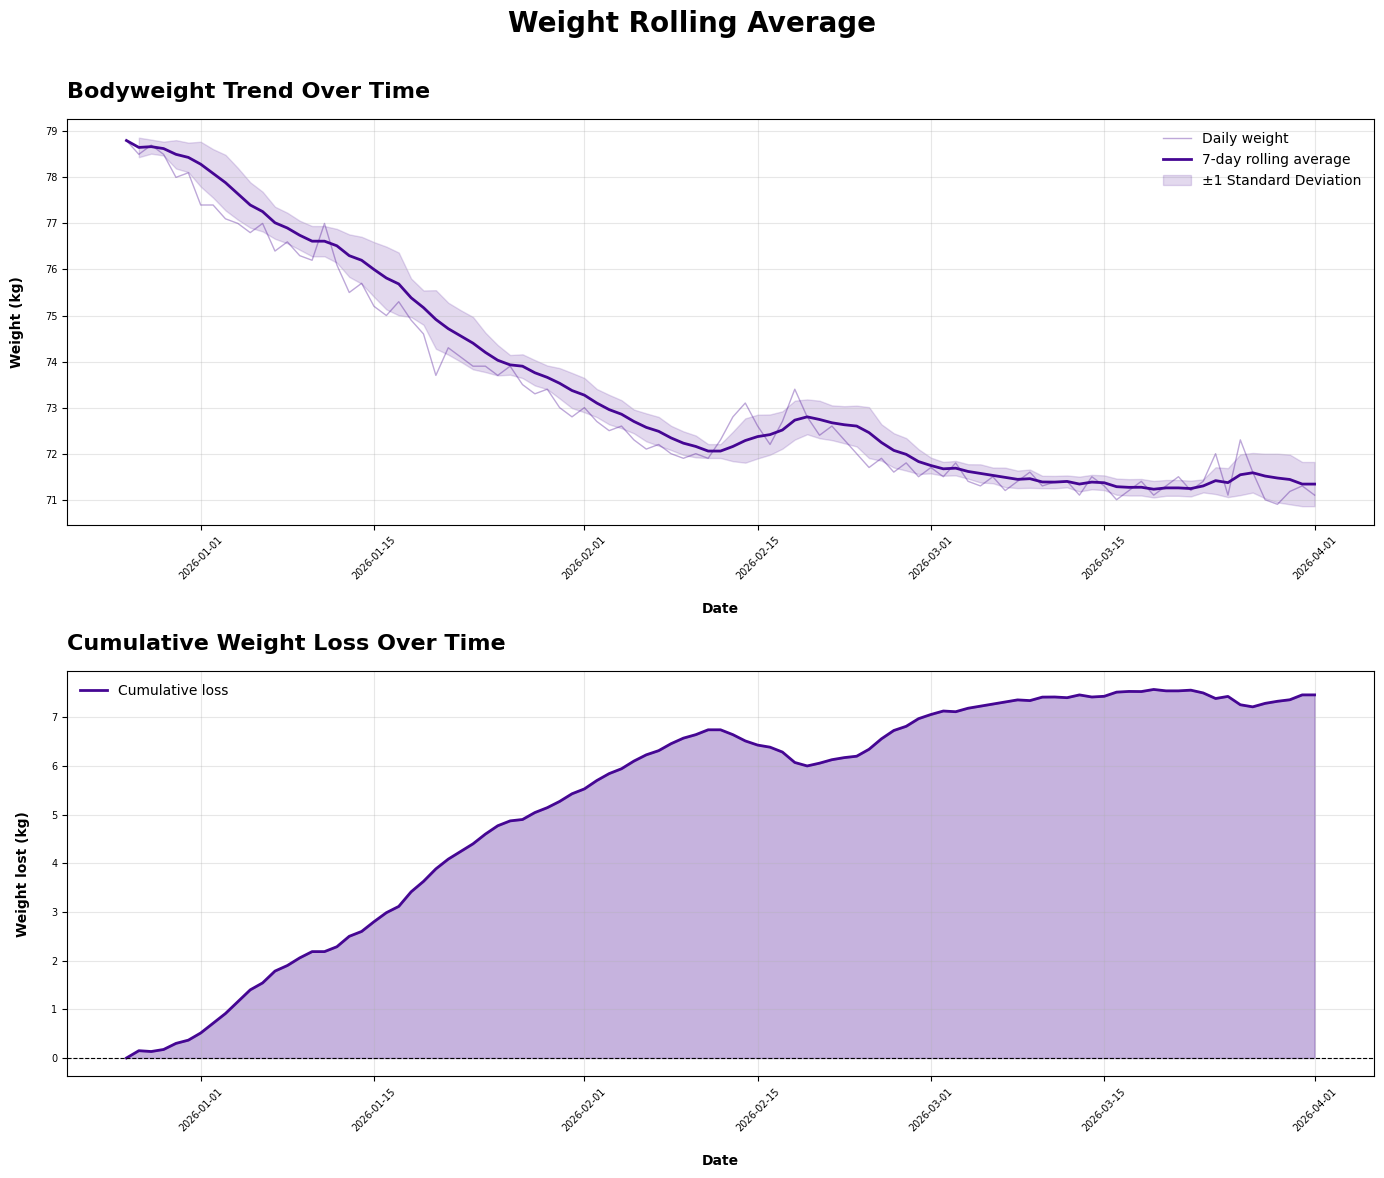

In [26]:
df["weightStd"] = df["weight"].rolling(window = 7, min_periods = 1).std()

fig, axes = plt.subplots(2, 1, figsize = (14, 12))
fig.suptitle("Weight Rolling Average\n", fontsize = 20, fontweight = "bold")

# Plot 1 : Weight Trend and Rolling Average
ax1 = axes[0]
ax1.plot(
    df["date"], 
    df["weight"], 
    color = darkPurple, 
    alpha = 0.35, 
    linewidth = 1, 
    label = "Daily weight"
)
ax1.plot(
    df["date"], 
    df["averageWeight"],
    color = darkPurple, 
    linewidth = 2, 
    label = "7-day rolling average"
)

ax1.fill_between(
    df["date"],
    df["averageWeight"] - df["weightStd"],
    df["averageWeight"] + df["weightStd"],
    alpha = 0.15, 
    color = darkPurple, 
    label = "±1 Standard Deviation"
)

ax1.set_title("Bodyweight Trend Over Time", loc="left")
ax1.set_xlabel("Date")
ax1.set_ylabel("Weight (kg)")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Cumulative Weight Loss 
ax2 = axes[1]
df["cumulativeLoss"] = df["weight"].iloc[0] - df["averageWeight"]

ax2.fill_between(
    df["date"], 
    df["cumulativeLoss"],
    alpha = 0.3, 
    color = darkPurple
)
ax2.plot(
    df["date"], 
    df["cumulativeLoss"],
    color = darkPurple, 
    linewidth = 2, 
    label = "Cumulative loss"
)

ax2.axhline(0, color="black", linewidth=0.8, linestyle = "--")
ax2.set_title("Cumulative Weight Loss Over Time", loc = "left")
ax2.set_xlabel("Date")
ax2.set_ylabel("Weight lost (kg)")
ax2.tick_params(axis = "x", rotation=45)
ax2.legend()
ax2.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

The 7-day rolling average shows an overall downward trend, indicating a consistent caloric deficit over the observed period. Variability in daily weight is higher during the early phase, depicted by a wider standard deviation band. This is consistent with larger short-term fluctuations, likely caused by changes in glycogen, water retention, and dietary variability during my aggressive deficit.

### 8.3 Macros and Calories

Calories alone do not tell the full story. The following four charts display daily intake and 7-day rolling averages for all tracked dietary variables simultaneously: calories, protein, carbohydrates, and fat. The goal is to observe how each macro varies over time and identify whether distinct behavioural phases are visible across all four signals at once.

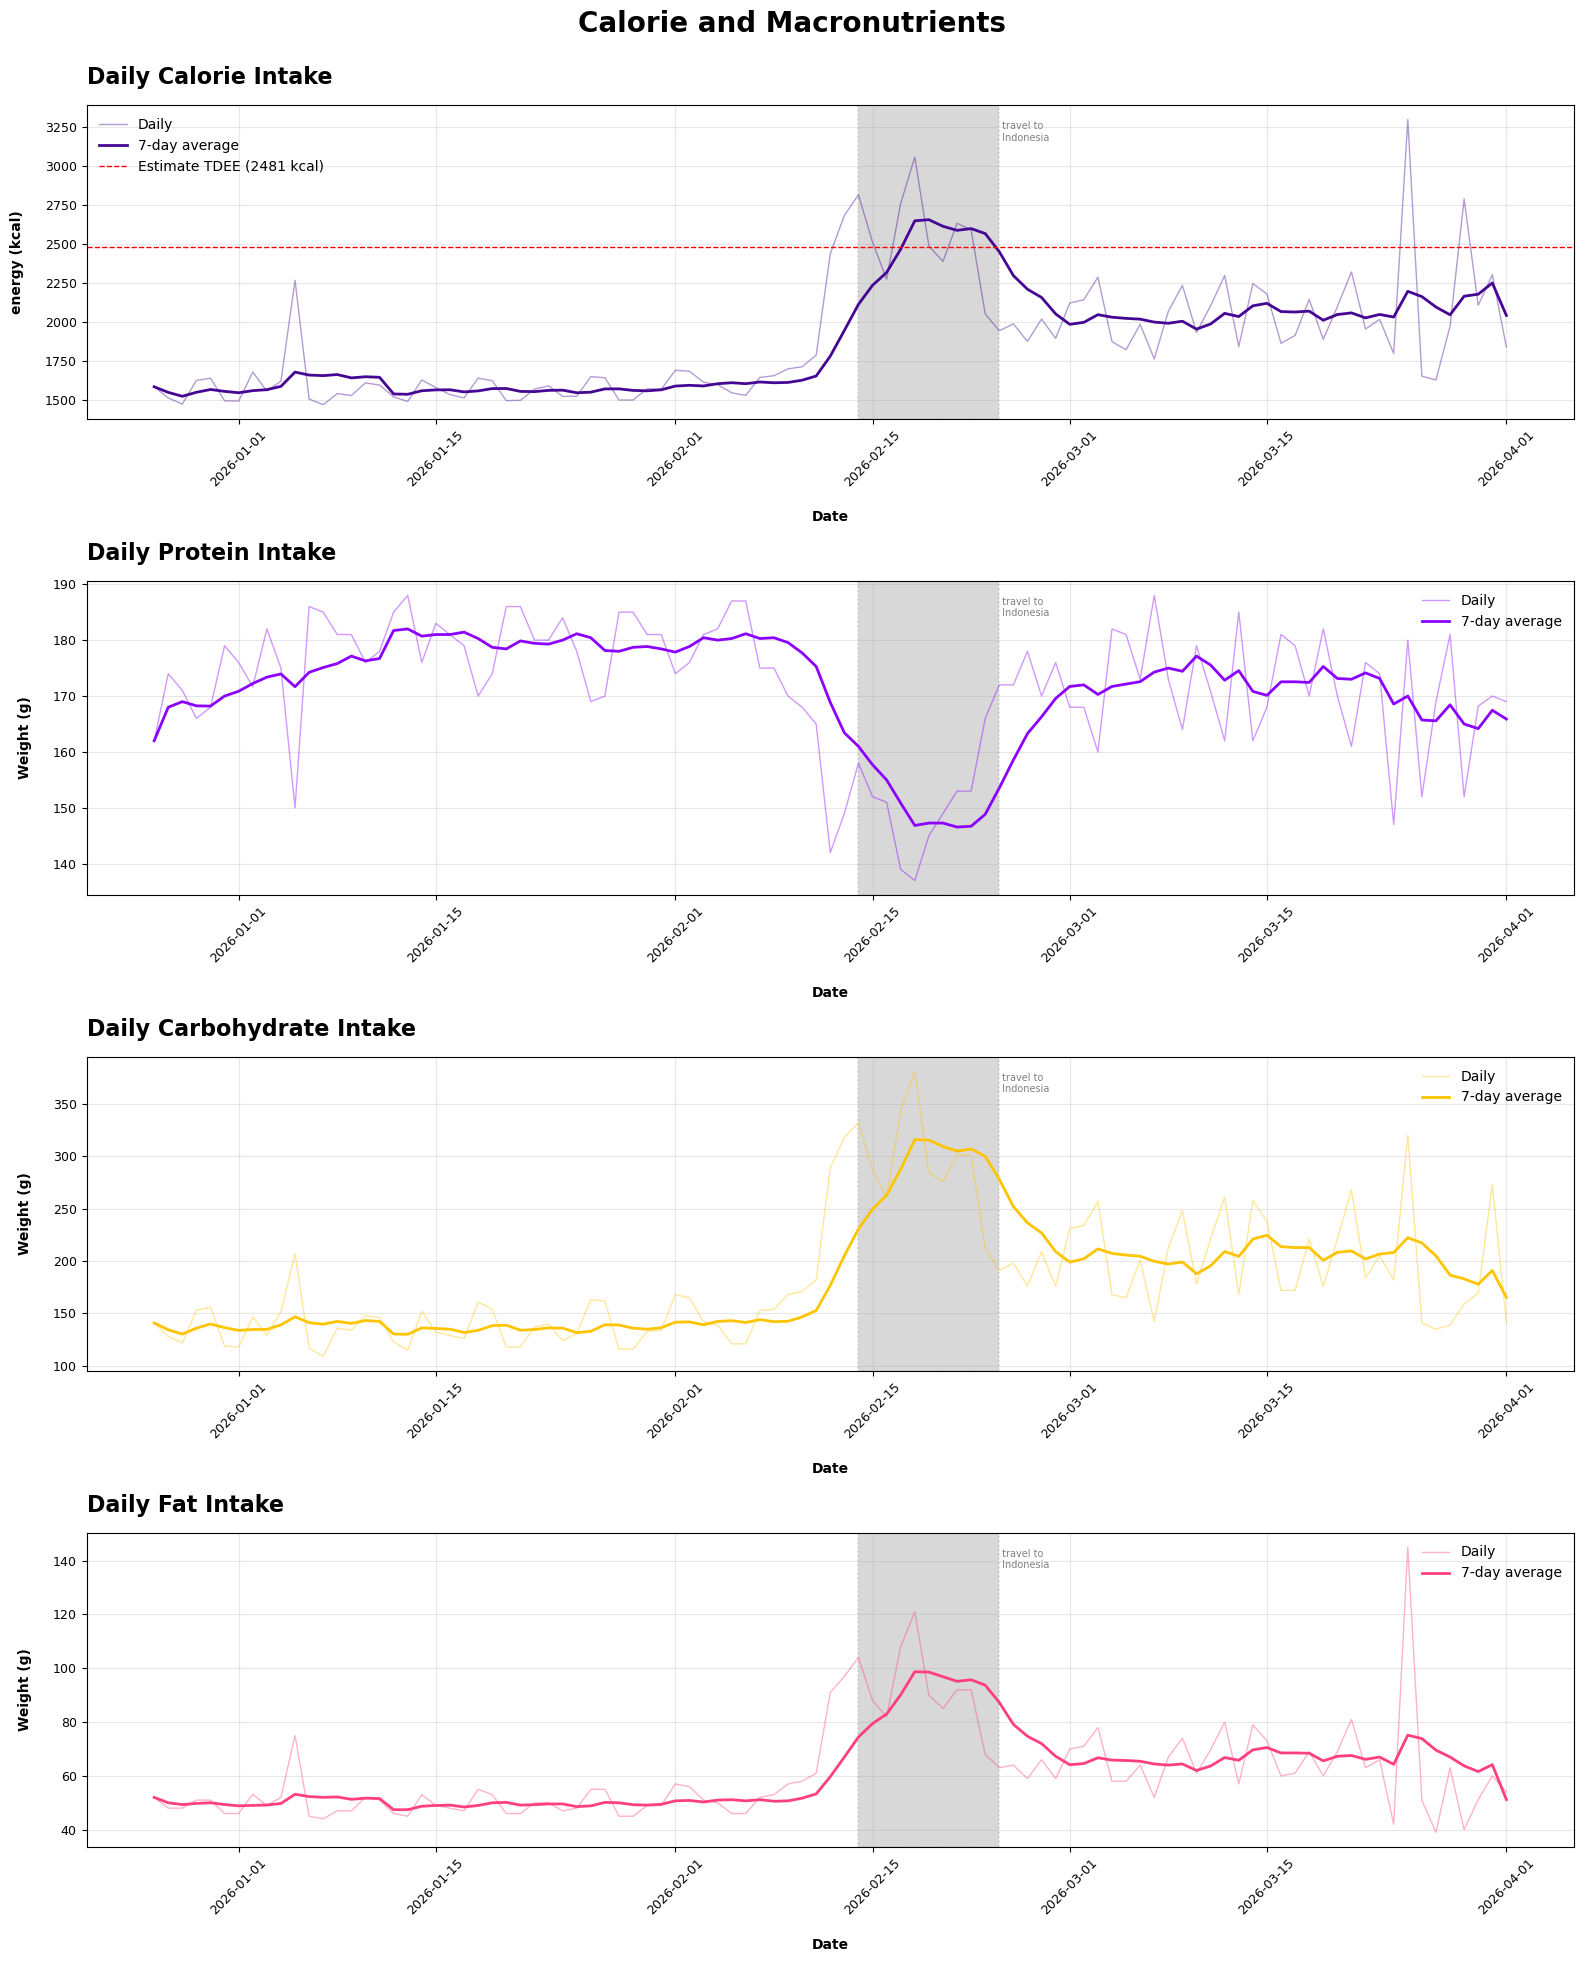

In [49]:
macros = [
    ("calorie", "averageCalorie", "Daily Calorie Intake","energy (kcal)", darkPurple),
    ("protein", "averageProtein", "Daily Protein Intake", "Weight (g)", purple),
    ("carbohydrate", "averageCarbohydrate", "Daily Carbohydrate Intake", "Weight (g)", yellow),
    ("fat", "averageFat", "Daily Fat Intake", "Weight (g)", pink),
]

fig, axes = plt.subplots(4, 1, figsize = (16, 20))
fig.suptitle("Calorie and Macronutrients\n", fontsize = 20, fontweight = "bold")

for ax, (raw, avg, title, unit, color) in zip(axes, macros):
    ax.plot(
        df["date"], df[raw],
        color = color, 
        alpha = 0.4, 
        linewidth = 1, 
        label = "Daily"
    )
    ax.plot(
        df["date"], df[avg],
        color = color, 
        linewidth = 2, 
        label = "7-day average"
    )

    tripStart = pd.Timestamp("2026-02-14")
    tripEnd = pd.Timestamp("2026-02-24")
    ax.axvspan(
        tripStart, 
        tripEnd, 
        color = "gray", 
        linestyle = ":", 
        linewidth = 1.2, 
        alpha = 0.3
    )
    ax.text(
        tripEnd, 
        0.95, 
        " travel to\n Indonesia",
        transform = ax.get_xaxis_transform(),
        fontsize = 7, 
        color = "gray", 
        va="top"
    )

    # TDEE reference line on calorie plot only
    if raw == "calorie":
        ax.axhline(
            personalTDEE, 
            color = "red", 
            linestyle = "--",
            linewidth = 1, 
            label = f"Estimate TDEE ({personalTDEE:.0f} kcal)"
        )

    ax.set_title(title, loc="left")
    ax.set_xlabel("Date")
    ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.legend()
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

The calorie trend confirms that I was on a deficit throughout the observation period, with the 7-day rolling average always beneath the Mifflin-St Jeor TDEE reference line.

There is a noticeable pattern on all four charts, the sharp transition visible in mid-February. This happens during the time I made a return home to Indonesia where I'm more lenient with my dietary habits, often having family meals, eating out, and just enjoying food. Calories, carbohydrates, and fat all rise sharply and simultaneously, while protein intake drops. It goes to show that I shifted away from my usual high-protein diet, to relatively higher fatty and carbohydrate meals.

Though this may signal as a break in my diet, and in my mind "The lack of discipline", it goes to show how the two different periods (structured vs unstructured eating) can vary in energy intake, and how it may effect one's goal to fatloss.


## 9. Attribute Correlation

Before building features or models, it is worth examining how the raw variables relate to each other. Correlation analysis serves two purposes here: to confirm expected relationships, and to flag unexpected ones that may reflect the confounding structure of the two-phase dataset.

### 9.1 Raw Attribute Correlation

A Pearson correlation matrix across the eight raw variables. This captures pairwise linear relationships as they were recorded (without any time-shifting or smoothing) to establish a baseline before engineered features are introduced.

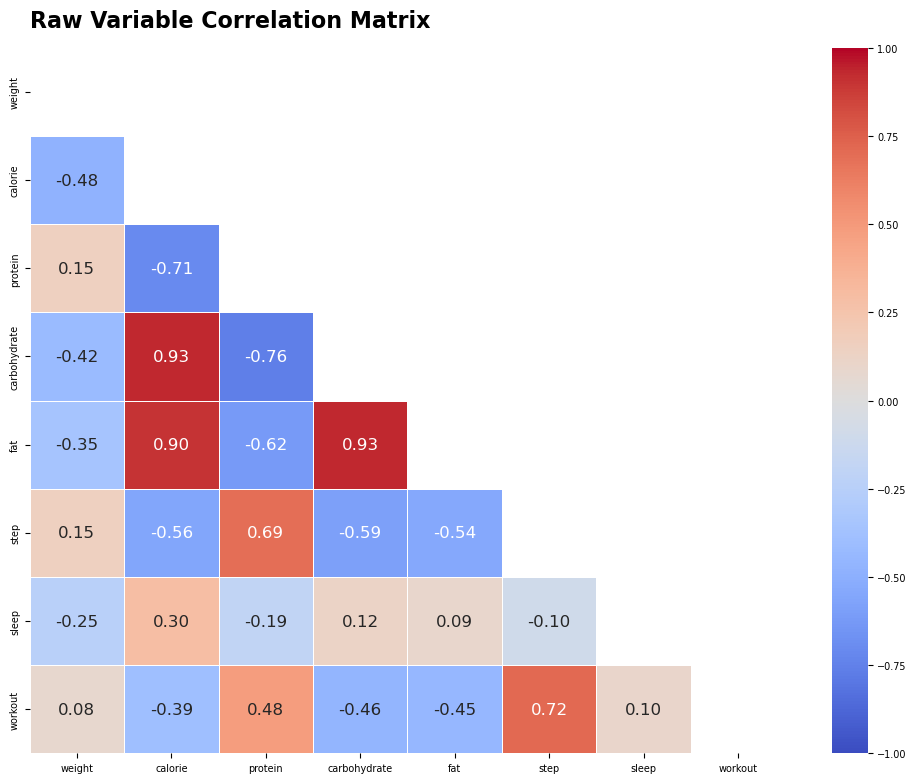

In [50]:
rawFeatures = ["weight", "calorie", "protein", "carbohydrate", "fat", "step", "sleep", "workout"]

corrRaw  = df[rawFeatures].corr()
maskRaw  = np.triu(np.ones_like(corrRaw, dtype = bool))

fig, ax = plt.subplots(figsize = (10,8))
sns.heatmap(
    corrRaw,
    mask = maskRaw,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    center = 0,
    vmin = -1, 
    vmax = 1,
    linewidths = 0.5,
    ax = ax
)

ax.set_title("Raw Variable Correlation Matrix", fontsize = 16, fontweight = "bold", loc = "left")
plt.tight_layout()
plt.show()

### Findings

The heatmap highlights several meaningful relationships in the dataset, many of which are driven by changes in behaviour over time rather than purely physiological effects.

Calories and body weight show a moderate negative correlation, which is counterintuitive. However, this reflects the underlying structure of the data where early in the period, I was at a higher body weight and following a more aggressive deficit with lower caloric intake. Over time, as body weight decreased and the diet became more sustainable, average calorie intake gradually increased. This phase shift explains the relationship.

Sleep doesn't show strong correlations with most variables. This was unexpected, as inconsistent sleep was assumed to influence multiple aspects of the dataset. The weak signal suggests either that sleep impacts variables not captured here (such as sleep quality or stress), or that its effects are indirect and not easily isolated within this feature set.

Macronutrient relationships are more structurally clear. Carbohydrates and fats both show strong positive correlations with total calorie intake, indicating they are the primary drivers of day-to-day energy variation. In contrast, protein shows a strong negative correlation with both carbs and fats, reflecting dietary prioritisation during the deficit phase, where protein intake was kept high while other macros were reduced. This pattern reverses during the Indonesia phase, where diet composition shifts significantly.

Gym and step count are also positively correlated. This is largely behavioural where gym days naturally involve walking to and from the gym, increasing daily steps.

Overall, the correlation matrix separates two distinct behavioural phases in the dataset, a structured cutting phase and a less controlled period during travel. Many of the strongest correlations are therefore explained by these regime changes rather than stable physiological relationships.

### 9.2 Engineered Feature Correlation with Weight Change
The raw correlation matrix compares variables that exist in the same row of data — the same day. But the body does not respond to food intake instantly. Weight change is a cumulative, delayed process. Eating 500 kcal above maintenance today does not show on the scale today.

To account for this, the engineered lag features are used instead: variables shifted by one day, and 3-day rolling averages of those shifts, to correlate yesterday's behaviour with today's smoothed weight change. This is a more physiologically meaningful comparison, and the one that drives the feature selection for the machine learning section.

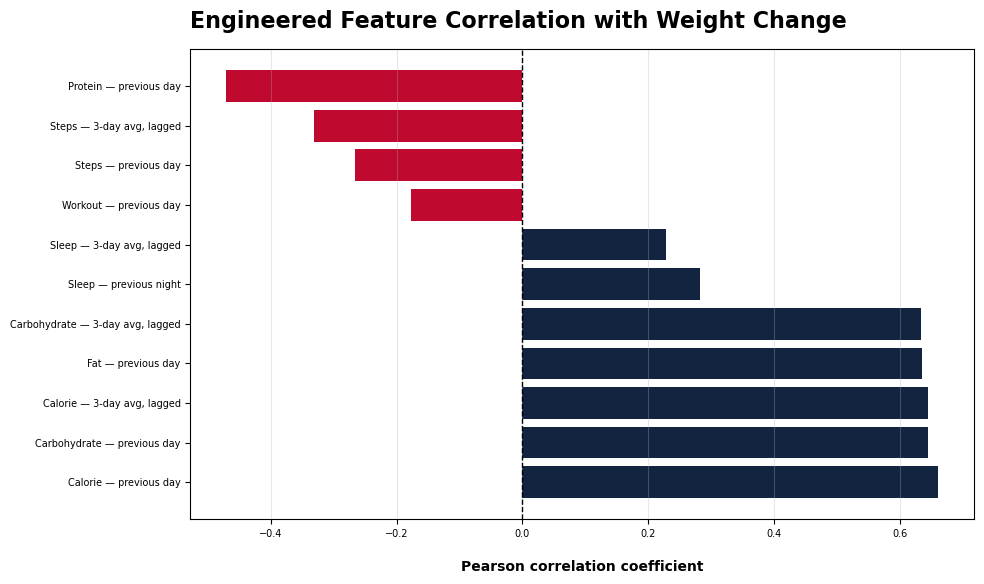

In [51]:
engineeredFeatures = ["deltaAverageWeight", "calorieLag1", "carbohydrateLag1", "proteinLag1", "fatLag1", "stepLag1", "sleepLag1", "workoutLag1", "calorie3dAverageLag1", "carbohydrate3dAverageLag1", "step3dAverageLag1", "sleep3dAverageLag1"]

corrEngineered = df[engineeredFeatures].corr()[["deltaAverageWeight"]].drop("deltaAverageWeight")
corrEngineered = corrEngineered.sort_values("deltaAverageWeight", ascending = False)

featureLabels = {
    "calorieLag1": "Calorie — previous day",
    "carbohydrateLag1": "Carbohydrate — previous day",
    "proteinLag1": "Protein — previous day",
    "fatLag1": "Fat — previous day",
    "stepLag1": "Steps — previous day",
    "sleepLag1": "Sleep — previous night",
    "workoutLag1": "Workout — previous day",
    "calorie3dAverageLag1": "Calorie — 3-day avg, lagged",
    "carbohydrate3dAverageLag1": "Carbohydrate — 3-day avg, lagged",
    "step3dAverageLag1": "Steps — 3-day avg, lagged",
    "sleep3dAverageLag1": "Sleep — 3-day avg, lagged",
}
corrEngineered.index = corrEngineered.index.map(lambda x: featureLabels.get(x, x))

fig, ax = plt.subplots(figsize = (10, 6))
colors = ["#132440" if v > 0 else "#BF092F" for v in corrEngineered["deltaAverageWeight"]]
ax.barh(corrEngineered.index, corrEngineered["deltaAverageWeight"], color = colors)
ax.axvline(0, color = "black", linestyle = "--", linewidth = 1)
ax.set_title("Engineered Feature Correlation with Weight Change", loc = "left")
ax.set_xlabel("Pearson correlation coefficient")
ax.grid(alpha = 0.3, axis = "x")
plt.tight_layout()
plt.show()

### Findings

This graph shows two sides of the story. Features that are associated with weight gain, and those associated with weight loss.

The features in the positive side, colored in blue, are dominated by lagged calorie, carbohydrate, and fat. To which they have a substantial association (better than 0.6) with deltaAverageWeight. Higher food intake, particularly calories from a diet high in carbohydrates and fats, is associated with weight gain on the next day. Not only that, but the 3 day rolling averages have an almost identical correlation coefficient to those with single lag features, suggesting that the relationship is consistent across both short and medium term windows, rather than being driven by just a single day's intake.

In contrast, the features in the negative side are dominated by lagged protein, step and workout. All features are inversely correlated with weight change, meaning eating more protein, taking more steps, and going to gym more often are associated with less weight gain. Protein intake from the previous day shows the strongest negative correlation, however given the correlation matrix above, protein and carbohydrates are strongly inversely correlated because of the two dietary phases, so some of the signals likely reflected the phase structure of the dataset, rather than protein intakes independent effect on weight change.

## 10. Calorie Intake vs Weight Change

The most fundamental question to anyone in a weightloss journey: does eating less actually correspond to weight loss? This section examines the relationship between the previous day's calorie intake and the next-day smoothed weight change as a scatter plot with a regression line, and as a distribution split by phase (deficit vs surplus relative to personal TDEE).

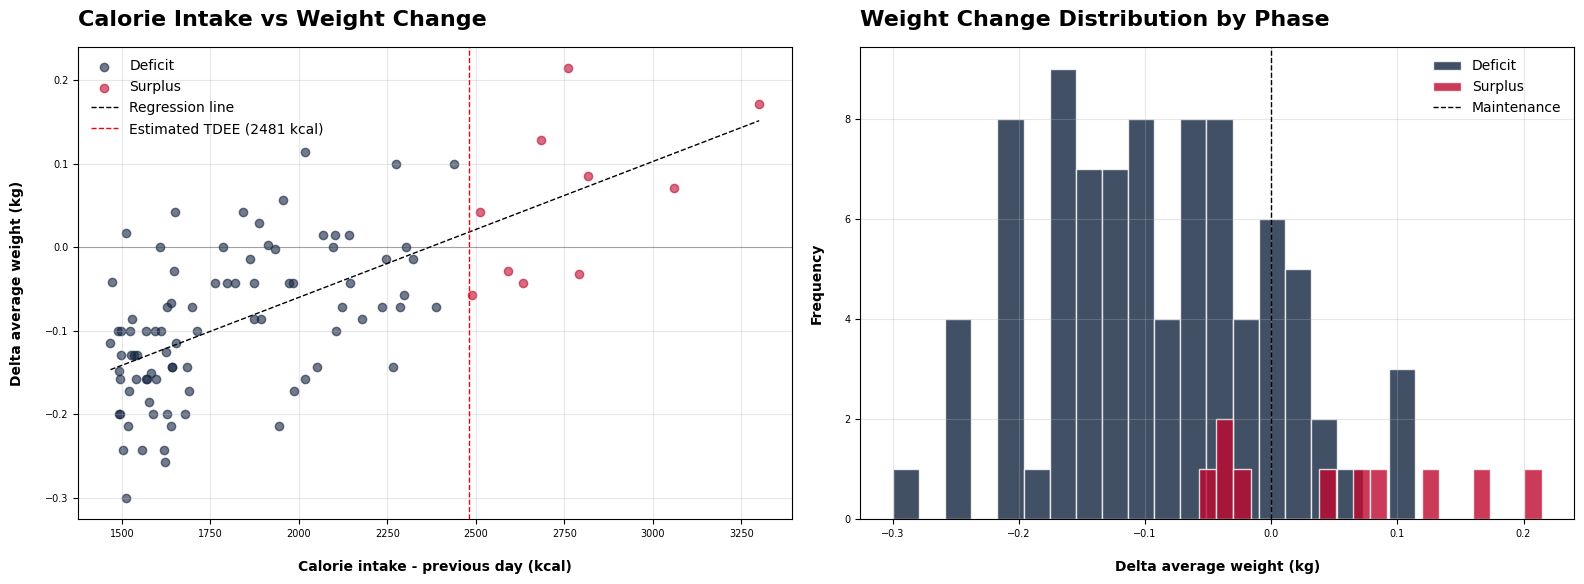

In [30]:
# Classify each day as deficit or surplus relative to personal TDEE
dfPlot = df[["calorieLag1", "deltaAverageWeight"]].dropna().copy()
dfPlot["phase"] = dfPlot["calorieLag1"].apply(
    lambda x: "Surplus" if x >= personalTDEE else "Deficit"
)

phaseColors = {"Deficit" : "#132440", "Surplus" : "#BF092F"}

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Plot 1: Scatter with regression line 
ax1 = axes[0]
for phase, group in dfPlot.groupby("phase"):
    ax1.scatter(
        group["calorieLag1"], 
        group["deltaAverageWeight"],
        label = phase, 
        color = phaseColors[phase], 
        alpha = 0.6
    )

# Regression line
m, b = np.polyfit(dfPlot["calorieLag1"], dfPlot["deltaAverageWeight"], 1)
xLine = np.linspace(dfPlot["calorieLag1"].min(), dfPlot["calorieLag1"].max(), 100)
ax1.plot(
    xLine, m * xLine + b, 
    color = "black", 
    linewidth = 1,
    linestyle = "--", 
    label = "Regression line"
)

ax1.axhline(
    0, 
    color = "black", 
    linewidth = 0.8,
    alpha = 0.3
)

ax1.axvline(
    personalTDEE, 
    color = "red", 
    linewidth = 1, 
    linestyle = "--",
    label = f"Estimated TDEE ({personalTDEE:.0f} kcal)")

ax1.set_title("Calorie Intake vs Weight Change", loc = "left")
ax1.set_xlabel("Calorie intake - previous day (kcal)")
ax1.set_ylabel("Delta average weight (kg)")
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2: Distribution of weight change by phase 
ax2 = axes[1]
for phase, group in dfPlot.groupby("phase"):
    ax2.hist(
        group["deltaAverageWeight"], 
        bins = 20, 
        alpha = 0.8,
        label = phase, 
        color = phaseColors[phase],
        edgecolor = "white"
    )

ax2.axvline(
    0, 
    color = "black",
    linewidth = 1, 
    linestyle = "--",
    label = "Maintenance"
)
ax2.set_title("Weight Change Distribution by Phase", loc = "left")
ax2.set_xlabel("Delta average weight (kg)")
ax2.set_ylabel("Frequency")
ax2.legend()
ax2.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Findings

The scatter plot confirms something simple but important, eating less consistently led to weight loss, and eating more led to weight gain or stalling. The regression line slopes in the direction energy balance theory predicts, and the vertical line representing my TDEE predicted using Mifflin-St Jeor's formula sits roughly where the data transitions from loss to gain. 

Though not perfect, the scatter is noisy. On any given day, the same calorie intake could produce very different outcomes on the scale. Some 1800 kcal days barely moved the scale. Some 2000 kcal days produced significant weight loss. However, I see this as an opportunity to explore why that is. Water retention, glycogen, sleep, and digestion, all add noise to a signal that only becomes clear over weeks, not days.

The distribution chart shows that deficit days cluster below zero, centred around −0.08 to −0.10 kg per day. 

The surplus days are interesting. Despite returning home and eating freely without restriction, the weight gain was moderate rather than dramatic. The scale moved, but not as much as the dietary shift might suggest, which hints that even unrestricted eating didn't push intake dramatically beyond true maintenance on most days.

## 11. Carbohydrates and Weight Change
The following charts aims to examine the relationship between previous day carbohydrate intake and next-day smoothed weight change using a scatter plot showing individual observations coloured by high vs low carb day, and a binned bar chart showing the average weight change across carbohydrate intake ranges.

The scatter uses the average carbohydrate intake as the threshold between high and low carb days. The binned chart groups observations into 50g carbohydrate ranges and shows the mean weight change within each group, with sample counts annotated on each bar.

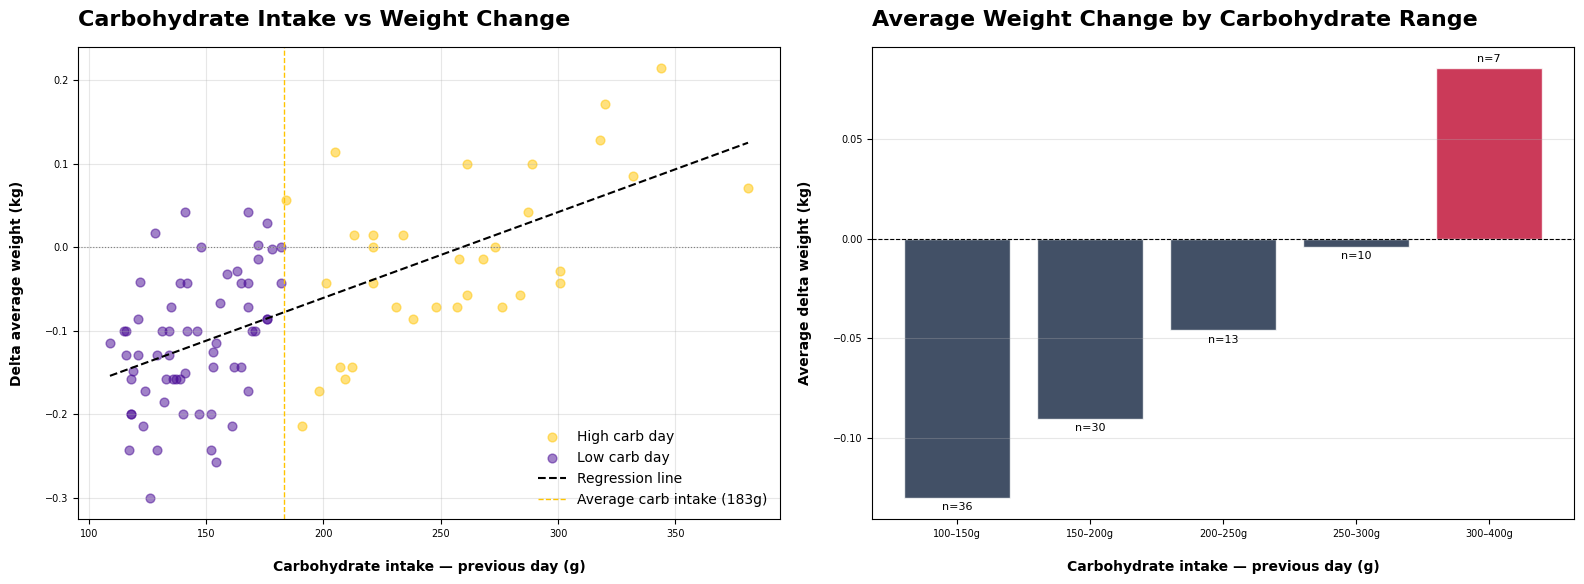

In [31]:
avgCarb = df["carbohydrateLag1"].mean()

dfCarbPlot = df[["carbohydrateLag1", "deltaAverageWeight"]].dropna().copy()
dfCarbPlot["carbPhase"] = dfCarbPlot["carbohydrateLag1"].apply(
    lambda x: "High carb day" if x >= avgCarb else "Low carb day"
)

carbColors = {"High carb day": yellow, "Low carb day": darkPurple}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1
ax1 = axes[0]
for phase, group in dfCarbPlot.groupby("carbPhase"):
    ax1.scatter(
        group["carbohydrateLag1"], group["deltaAverageWeight"],
        label = phase, 
        color = carbColors[phase], 
        alpha = 0.5, 
        s = 40
    )

m, b = np.polyfit(dfCarbPlot["carbohydrateLag1"], dfCarbPlot["deltaAverageWeight"], 1)
xLine = np.linspace(dfCarbPlot["carbohydrateLag1"].min(), dfCarbPlot["carbohydrateLag1"].max(), 100)
ax1.plot(
    xLine, m * xLine + b, 
    color = "black", 
    linewidth = 1.5,
    linestyle = "--", 
    label = "Regression line"
)

ax1.axhline(
    0, 
    color = "gray", 
    linewidth = 0.8, 
    linestyle = ":" 
)
ax1.axvline( 
    avgCarb, 
    color = yellow, 
    linewidth = 1, linestyle = "--",
    label = f"Average carb intake ({avgCarb:.0f}g)"
)

ax1.set_title("Carbohydrate Intake vs Weight Change", loc = "left")
ax1.set_xlabel("Carbohydrate intake — previous day (g)")
ax1.set_ylabel("Delta average weight (kg)")
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2 
ax2 = axes[1]
bins   = [0, 100, 150, 200, 250, 300, 400, 800]
labels = ["<100g", "100–150g", "150–200g", "200–250g", "250–300g", "300–400g", ">400g"]

dfCarbPlot["carbBin"] = pd.cut(dfCarbPlot["carbohydrateLag1"], bins = bins, labels = labels)
binMeans  = dfCarbPlot.groupby("carbBin", observed = True)["deltaAverageWeight"].mean()
binCounts = dfCarbPlot.groupby("carbBin", observed = True)["deltaAverageWeight"].count()

barColors = ["#BF092F" if v > 0 else "#132440" for v in binMeans]
bars = ax2.bar(
    binMeans.index, 
    binMeans.values, 
    color = barColors, 
    alpha = 0.8, 
    edgecolor = "white" )
ax2.bar_label(bars, labels = [f"n={c}" for c in binCounts], padding = 3, fontsize = 8)
ax2.axhline(
    0, 
    color = "black", 
    linewidth = 0.8, 
    linestyle = "--"
)
ax2.set_title("Average Weight Change by Carbohydrate Range", loc = "left")
ax2.set_xlabel("Carbohydrate intake — previous day (g)")
ax2.set_ylabel("Average delta weight (kg)")
ax2.grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.show()

### Findings

The scatter plot confirms a positive relationship between carbohydrate intake and next-day weight change. Low carb days clustered closely in the weight loss region located in the bottom left corner,  while high carb days progressively shifts toward zero or gain. 

The binned chart shows a clear consumption response relationship. Across the first four intake ranges from 100g to 300g, the average weight change trends upward with each additional 50g of carbohydrate intake.

- < 150g - deepest average loss at approximately −0.12 kg, representing 
  the most structured and disciplined deficit days
- 150–200g - consistent loss at approximately −0.09 kg
- 200–250g - loss narrows to approximately −0.05 kg, approaching maintenance
- 250–300g - essentially flat at near zero, signifying the transition between 
  deficit and surplus outcomes
- \> 300g - the only group producing average weight gain, driven by the phase where I was in Indonesia, carbohydrates, total calories, and dietary freedom all peaked at the same time.

The consistent gradient across the first four groups, where dietary phase is relatively consistent, identifies a meaningful pattern. Carbohydrate intake has a measurable, stepwise relationship with next-day scale weight, independent of the overall direction of the diet.

The caveat worth acknowledging is the final group. With only 7 observations and a strong overlap with the Indonesia phase, the weight gain above 300g cannot be the cause of carbohydrates alone. Total calorie surplus and reduced activity also falls in that bracket. 

## 12. Activity and Sleep vs Weight Change

Beyond food, three non-dietary variables were tracked daily: step count, sleep duration, and whether I went to the gym or not. This section examines whether these activity and recovery variables show a meaningful relationship with next-day weight change, and if so, in which direction.

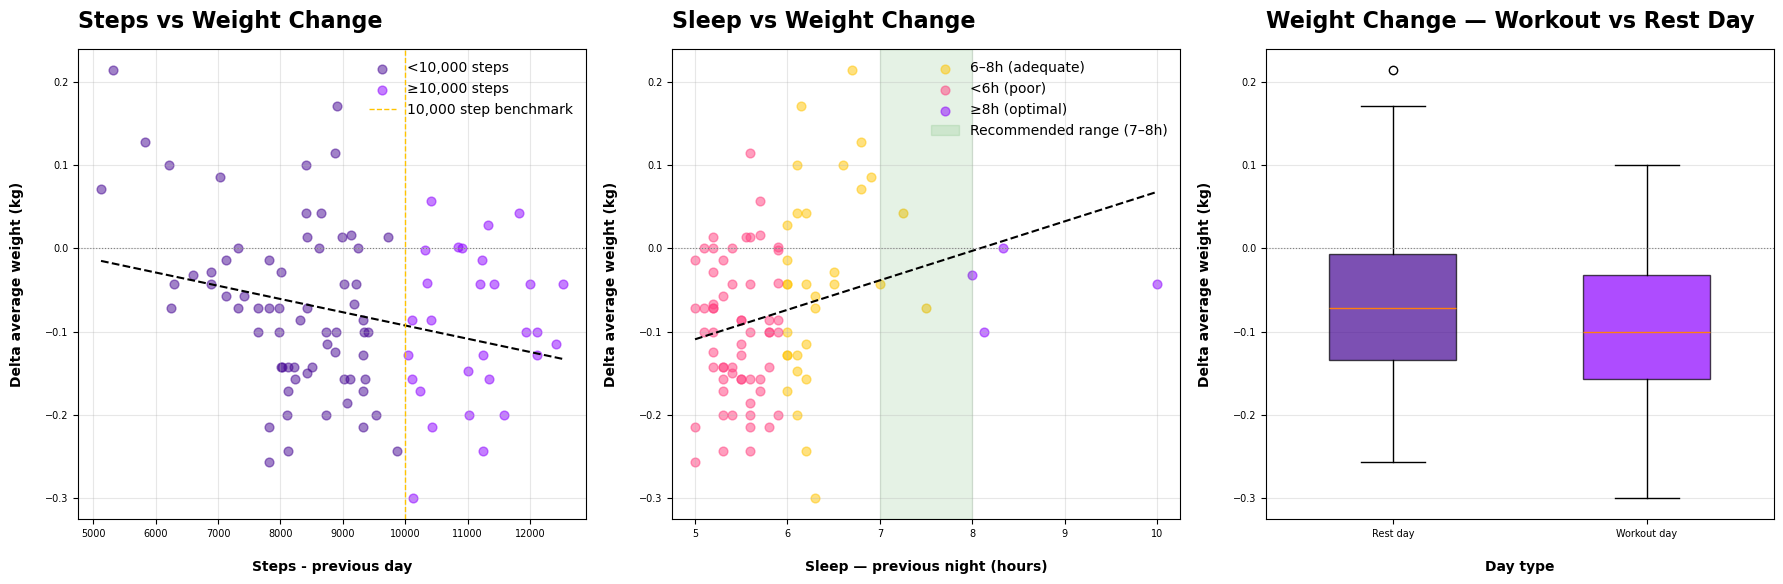

In [52]:
avgSteps = df["stepLag1"].mean()

fig, axes = plt.subplots(1, 3, figsize = (18, 6))

# Plot 1: Steps 
ax1 = axes[0]
dfSteps = df[["stepLag1", "deltaAverageWeight"]].dropna().copy()
dfSteps["stepPhase"] = dfSteps["stepLag1"].apply(
    lambda x: "≥10,000 steps" if x >= 10000 else "<10,000 steps"
)
stepColors = {"≥10,000 steps": purple, "<10,000 steps": darkPurple}

for phase, group in dfSteps.groupby("stepPhase"):
    ax1.scatter(
        group["stepLag1"], group["deltaAverageWeight"],
        label = phase, 
        color = stepColors[phase], 
        alpha = 0.5, 
        s = 40
    )

m, b = np.polyfit(dfSteps["stepLag1"], dfSteps["deltaAverageWeight"], 1)
xLine = np.linspace(dfSteps["stepLag1"].min(), dfSteps["stepLag1"].max(), 100)
ax1.plot(
    xLine, m * xLine + b, 
    color = "black",  
    linewidth = 1.5, 
    linestyle = "--"
)
ax1.axhline(
    0, 
    color = "gray", 
    linewidth = 0.8, 
    linestyle = ":"
)
ax1.axvline(
    10000, 
    color = yellow, 
    linewidth = 1, 
    linestyle = "--", 
    label = "10,000 step benchmark"
)
ax1.set_title("Steps vs Weight Change", loc = "left")
ax1.set_xlabel("Steps - previous day")
ax1.set_ylabel("Delta average weight (kg)")
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2: Sleep
ax2 = axes[1]
dfSleep = df[["sleepLag1", "deltaAverageWeight"]].dropna().copy()

def sleepBracket(hrs):
    if hrs < 6:   
        return "<6h (poor)"
    elif hrs < 8: 
        return "6–8h (adequate)"
    else:         
        return "≥8h (optimal)"

dfSleep["sleepBracket"] = dfSleep["sleepLag1"].apply(sleepBracket)
sleepColors = {"<6h (poor)": pink, "6–8h (adequate)": yellow, "≥8h (optimal)": purple}

for bracket, group in dfSleep.groupby("sleepBracket"):
    ax2.scatter(
        group["sleepLag1"], group["deltaAverageWeight"],
        label = bracket, 
        color = sleepColors[bracket], 
        alpha = 0.5, 
        s = 40
    )

m, b = np.polyfit(dfSleep["sleepLag1"], dfSleep["deltaAverageWeight"], 1)
xLine = np.linspace(dfSleep["sleepLag1"].min(), dfSleep["sleepLag1"].max(), 100)
ax2.plot(
    xLine, m * xLine + b, 
    color = "black", 
    linewidth = 1.5, 
    linestyle = "--"
)
ax2.axhline(
    0, 
    color = "gray", 
    linewidth = 0.8, 
    linestyle = ":"
)
ax2.axvspan(
    7, 8, 
    alpha = 0.1, 
    color = "green", 
    label = "Recommended range (7–8h)" 
)
ax2.set_title("Sleep vs Weight Change", loc = "left")
ax2.set_xlabel("Sleep — previous night (hours)")
ax2.set_ylabel("Delta average weight (kg)")
ax2.legend()
ax2.grid(alpha = 0.3)

# Plot 3: Workout
ax3 = axes[2]
dfWorkout = df[["workoutLag1", "deltaAverageWeight"]].dropna().copy()
dfWorkout["workoutLabel"] = dfWorkout["workoutLag1"].apply(
    lambda x: "Workout day" if x == 1 else "Rest day"
)

workoutGroups = [
    dfWorkout[dfWorkout["workoutLabel"] == "Rest day"]["deltaAverageWeight"],
    dfWorkout[dfWorkout["workoutLabel"] == "Workout day"]["deltaAverageWeight"]
]

bp = ax3.boxplot(
    workoutGroups, 
    tick_labels = ["Rest day", "Workout day"],
    patch_artist = True, 
    widths = 0.5
)
bp["boxes"][0].set_facecolor(darkPurple)
bp["boxes"][1].set_facecolor(purple)
for patch in bp["boxes"]:
    patch.set_alpha(0.7)

ax3.axhline(
    0, 
    color = "gray", 
    linewidth = 0.8, 
    linestyle = ":"
)
ax3.set_title("Weight Change — Workout vs Rest Day", loc = "left")
ax3.set_xlabel("Day type")
ax3.set_ylabel("Delta average weight (kg)")
ax3.grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.show()

### Findings

**Steps**  
The scatter shows a consistent negative trend. More steps taken the previous day is associated with more weight lost the next day, which aligns with the role of steps as a proxy for non-exercise activity thermogenesis (NEAT). The relationship is noisy at the individual day level, as expected, but the direction is reliable. Most days fell below the 10000 step benchmark, and the deepest weight loss observations tend to cluster in that high step count region above it.

**Sleep** 
The sleep chart produces a counterintuitive result. The regression line slopes upward, suggesting that more sleep is weakly associated with more weight gain. Before concluding anything from this, it is worth noting that the majority of my longer sleep nights occurred during my time in Indonesia, where food intake was simultaneously higher. Sleep duration here is likely acting as a proxy for the dietary phase rather than as an independent signal. This is consistent with the observation from the correlation matrix, where sleep showed weak direct relationships with most variables.

**Workout** 
Both rest days and workout days produced average weight loss, with both boxes centred below zero. Workout days show a slightly higher median than rest days, which may reflect short-term water retention from muscle recovery temporarily masking fat loss on the scale. The interquartile ranges overlap substantially, and with the sample size available, this difference cannot be interpreted with confidence. What it does suggest is that going to the gym did not meaningfully stall progress.

## 13. Multivariable Analysis - Carbs, Calories, and Weight Change

Calories and carbohydrates do not operate in isolation. This section combines both variables to examine whether carbohydrate intake adds a layer of noise on top of the calorie signal, and whether certain calorie/carb combinations systematically produce better or worse outcomes on the scale.

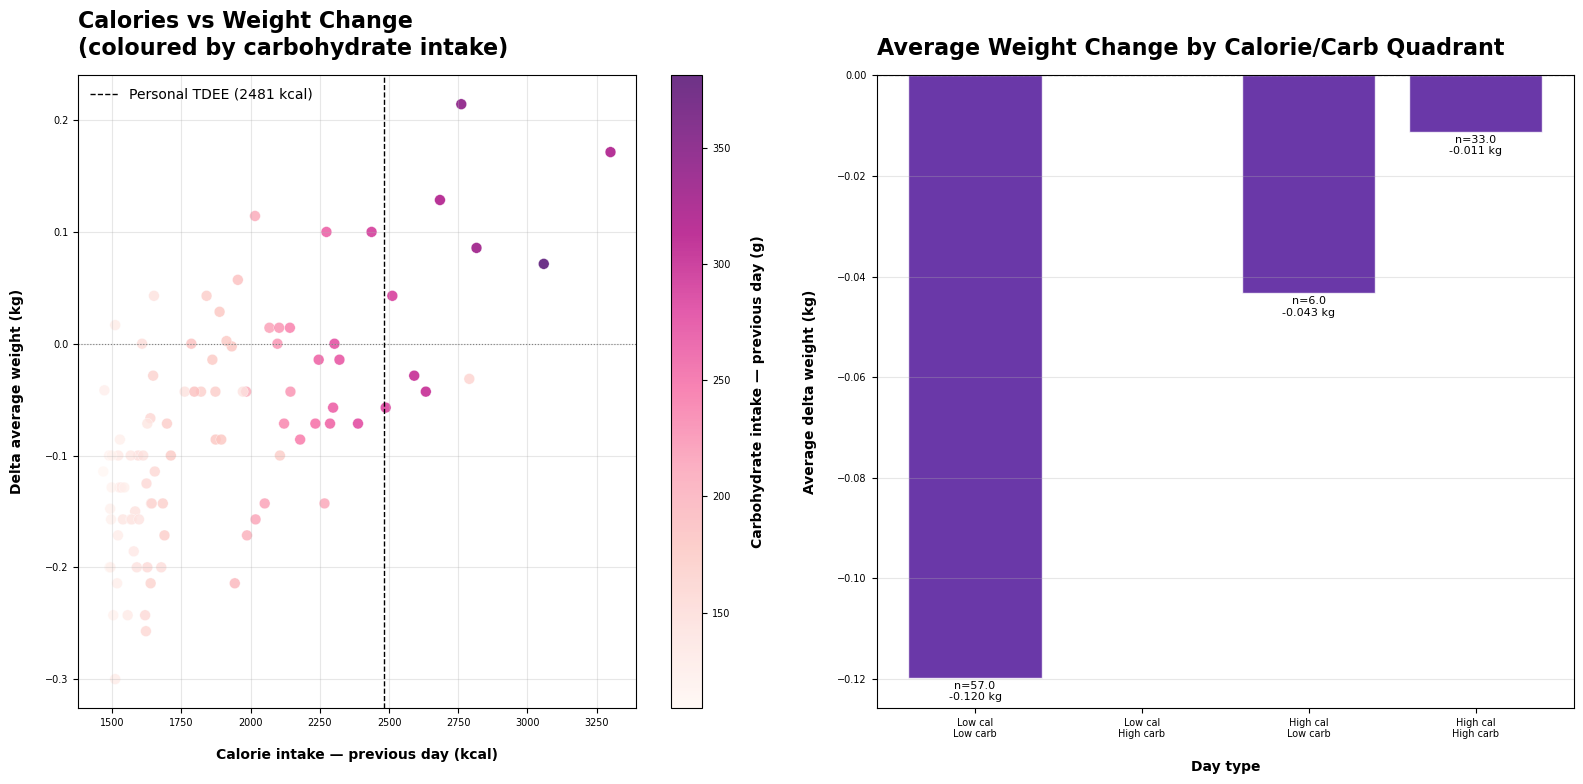

In [56]:
dfMulti = df[["calorieLag1", "carbohydrateLag1", "deltaAverageWeight"]].dropna().copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Scatter with carb encoded as colour 
ax1 = axes[0]
sc = ax1.scatter(
    dfMulti["calorieLag1"],dfMulti["deltaAverageWeight"],
    c = dfMulti["carbohydrateLag1"],
    cmap = "RdPu",
    alpha = 0.8,
    s = 60,
    edgecolors = "white",
    linewidths = 0.3
)
plt.colorbar(sc, ax = ax1, label = "Carbohydrate intake — previous day (g)")

ax1.axhline(
    0, 
    color = "gray", 
    linewidth = 0.8, 
    linestyle = ":"
)
ax1.axvline(
    personalTDEE, 
    color = "black", 
    linewidth = 1, 
    linestyle = "--",
    label = f"Personal TDEE ({personalTDEE:.0f} kcal)"
)
ax1.set_title("Calories vs Weight Change\n(coloured by carbohydrate intake)", loc = "left")
ax1.set_xlabel("Calorie intake — previous day (kcal)")
ax1.set_ylabel("Delta average weight (kg)")
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2: Quadrant analysis 
ax2 = axes[1]

avgCalorie = dfMulti["calorieLag1"].mean()
avgCarb = dfMulti["carbohydrateLag1"].mean()

def quadrant(row):
    hiCal = row["calorieLag1"] >= avgCalorie
    hiCarb = row["carbohydrateLag1"] >= avgCarb
    if hiCal and hiCarb:       
        return "High cal\nHigh carb"
    elif hiCal and not hiCarb: 
        return "High cal\nLow carb"
    elif not hiCal and hiCarb: 
        return "Low cal\nHigh carb"
    else:                      
        return "Low cal\nLow carb"

dfMulti["quadrant"] = dfMulti.apply(quadrant, axis = 1)

quadrantOrder = ["Low cal\nLow carb", "Low cal\nHigh carb", "High cal\nLow carb", "High cal\nHigh carb"]
quadrantMeans = dfMulti.groupby("quadrant")["deltaAverageWeight"].mean().reindex(quadrantOrder)
quadrantCounts = dfMulti.groupby("quadrant")["deltaAverageWeight"].count().reindex(quadrantOrder)
quadrantColors = [darkPurple if v < 0 else pink for v in quadrantMeans]

bars = ax2.bar(
    quadrantMeans.index, 
    quadrantMeans.values,
    color = quadrantColors, 
    alpha = 0.8, 
    edgecolor = "white"
)
ax2.bar_label(
    bars, 
    labels = [f"n={c}\n{v:.3f} kg" for c, v in zip(quadrantCounts, quadrantMeans)],
    padding = 2, 
    fontsize = 8
)
ax2.axhline(
    0, 
    color = "black", 
    linewidth = 0.8, 
    linestyle = "--"
)
ax2.set_title("Average Weight Change by Calorie/Carb Quadrant", loc = "left")
ax2.set_xlabel("Day type")
ax2.set_ylabel("Average delta weight (kg)")
ax2.grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.show()

### Findings

The colour gradient in the scatter plot makes the combined effect of calories and carbohydrates immediately visible. The palest dots, representing the lowest carbohydrate intake, almost entirely occupying the bottom-left region of the chart, where calorie intake is low and weight loss is most consistent. As carbohydrate intake increases, represented by the darkening colour, points progressively move upwards toward the zero line and into weight-gain territory. This reinforces that carbohydrate intake adds a layer of noise on top of the calorie signal, shifting daily scale weight independent of the overall caloric intake.

The quadrant analysis breaks this down more concisely. The Low cal, Low carb quadrant (n=57) produced the deepest average loss at −0.120 kg, representing the majority of structured deficit days. The Low cal, High carb quadrant contains no observations, which reflects how my approach worked in practice — on lower calorie days, carbohydrates were kept low by design. The High cal, High carb quadrant (n=33) produced an average of just −0.011 kg, essentially flat, accounting for the bulk of the Indonesia period.

The most notable finding is that even the High cal, High carb quadrant still produced a slight net loss on average. Despite unrestricted eating during that period, intake did not dramatically overshoot true maintenance on most days. The scale moved, but not as much as the dietary shift suggested it would.

## 14. Personal TDEE Over Time

This section presents the central result of the analysis. The derived daily TDEE estimates are plotted over time alongside a 7-day rolling average and ±1 standard deviation band, with the Mifflin-St Jeor formula as a reference line. The gap between the two is the number that actually matters for calibrating a sustainable deficit.

In [63]:
df["tdeeStd"]      = df["tdeeEstimate"].rolling(window = 7, min_periods = 1).std()
personalTDEEStd    = df["tdeeEstimate"].std()
personalTDEEMedian = df["tdeeRolling"].median()

print("Personal TDEE Summary")
print(f"\tMean (rolling avg)\t: {personalTDEE:.0f} kcal")
print(f"\tMedian (rolling avg)\t: {personalTDEEMedian:.0f} kcal")
print(f"\tStd (daily estimate)\t: {personalTDEEStd:.0f} kcal")
print(f"\tMifflin-St Jeor TDEE\t: {tdeeFormula:.0f} kcal")
print(f"\tDifference\t\t: {personalTDEE - tdeeFormula:+.0f} kcal ({(personalTDEE - tdeeFormula) / tdeeFormula * 100:+.1f}%)")

Personal TDEE Summary
	Mean (rolling avg)	: 2481 kcal
	Median (rolling avg)	: 2480 kcal
	Std (daily estimate)	: 582 kcal
	Mifflin-St Jeor TDEE	: 2697 kcal
	Difference		: -216 kcal (-8.0%)


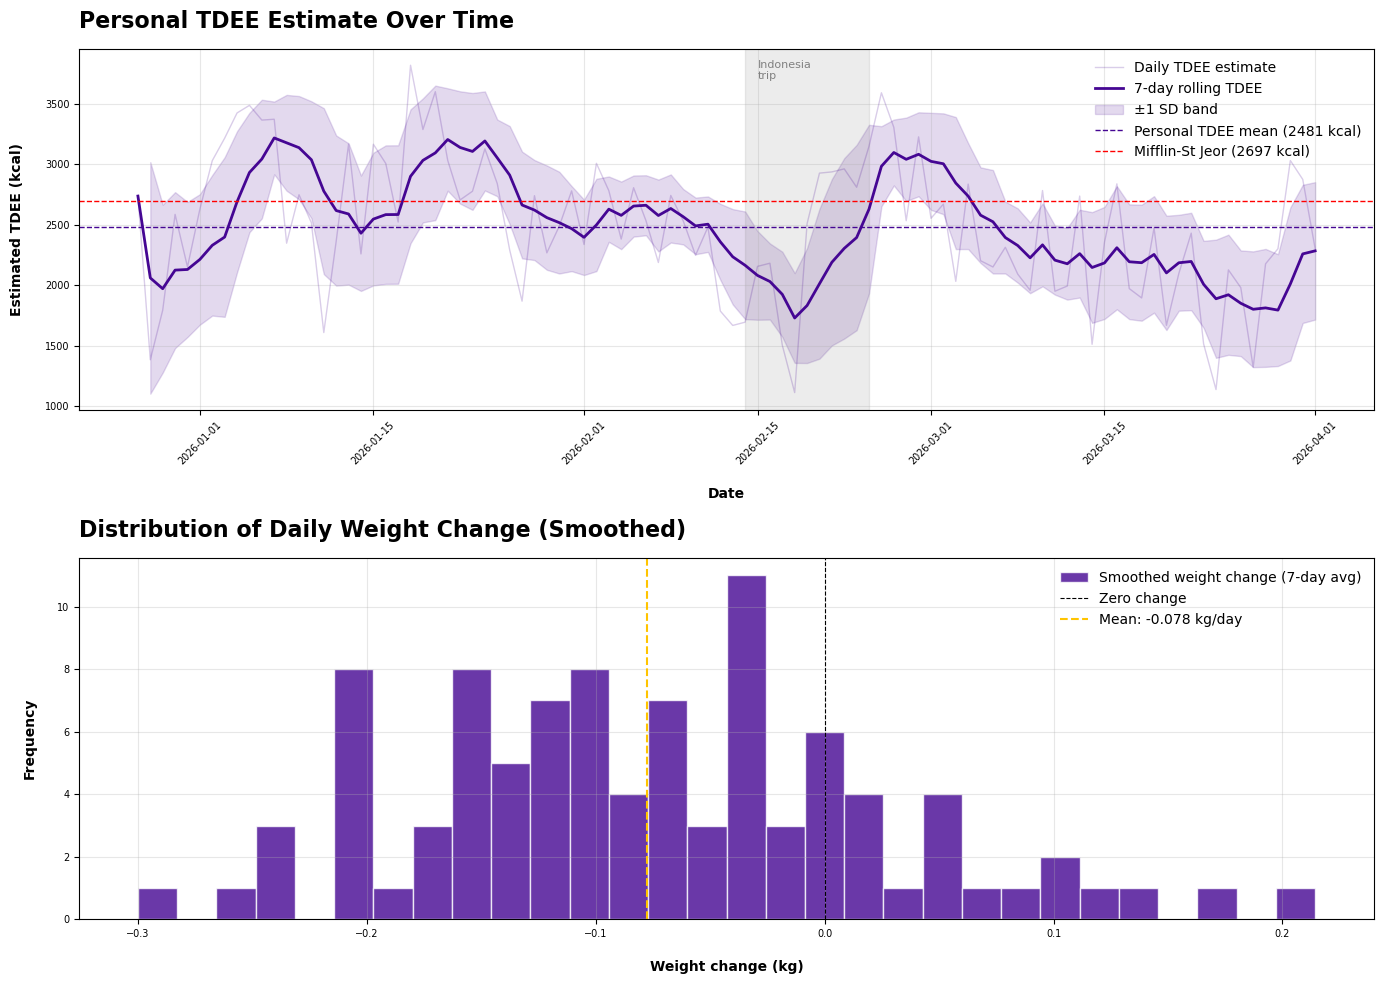

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: TDEE over time
ax1 = axes[0]
ax1.plot(
    df["date"], df["tdeeEstimate"],
    color = darkPurple, 
    alpha = 0.2, 
    linewidth = 1, 
    label = "Daily TDEE estimate"
)
ax1.plot(
    df["date"], df["tdeeRolling"],
    color = darkPurple, 
    linewidth = 2,
    label = "7-day rolling TDEE"
)
ax1.fill_between(
    df["date"], df["tdeeRolling"] - df["tdeeStd"], df["tdeeRolling"] + df["tdeeStd"],
    alpha = 0.15, 
    color = darkPurple, 
    label = "±1 SD band"
)

ax1.axhline(
    personalTDEE, 
    color = darkPurple, 
    linewidth = 1,
    linestyle = "--", 
    label = f"Personal TDEE mean ({personalTDEE:.0f} kcal)"
)

tripStart = pd.Timestamp("2026-02-14")
tripEnd = pd.Timestamp("2026-02-24")
ax1.axvspan(
    tripStart, tripEnd, 
    color = "gray", 
    alpha = 0.15, 
)
ax1.text(
    tripStart + pd.Timedelta(days = 1), 
    0.97, 
    "Indonesia\ntrip", 
    fontsize = 8, 
    color = "gray", 
    va = "top",
    transform = ax1.get_xaxis_transform()
)
ax1.axhline(
    tdeeFormula, 
    color = "red", 
    linewidth = 1,
    linestyle = "--", 
    label = f"Mifflin-St Jeor ({tdeeFormula:.0f} kcal)"
)

ax1.set_title("Personal TDEE Estimate Over Time", loc = "left")
ax1.set_xlabel("Date")
ax1.set_ylabel("Estimated TDEE (kcal)")
ax1.tick_params(axis = "x", rotation = 45)
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2: Delta weight distributions
ax2 = axes[1]
ax2.hist(
    df["deltaAverageWeight"].dropna(), 
    bins = 30, 
    alpha = 0.8,
    color = darkPurple, 
    edgecolor = "white", 
    label = "Smoothed weight change (7-day avg)"
)
ax2.axvline(
    0, 
    color = "black", 
    linewidth = 0.8, 
    linestyle = "--", 
    label = "Zero change"
)
ax2.axvline(
    df["deltaAverageWeight"].mean(), 
    color = yellow, 
    linewidth=1.5,
    linestyle="--", 
    label = f"Mean: {df['deltaAverageWeight'].mean():.3f} kg/day"
)

ax2.set_title("Distribution of Daily Weight Change (Smoothed)", loc = "left")
ax2.set_xlabel("Weight change (kg)")
ax2.set_ylabel("Frequency")
ax2.legend()
ax2.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Findings

The result of this analysis is that my personal TDEE, derived from 95 days of self-tracked data, is estimated at **2481 kcal**, **216 kcal below** the Mifflin-St Jeor formula estimate of 2,697 kcal. That gap is meaningful. Operating at the formula's estimate would have produced a smaller deficit than intended on most days, and possibly no deficit at all during the early weeks where I was already eating conservatively. The data-derived estimate is the more accurate starting point for dieting.

The TDEE estimate over time is highly variable, particularly in the early weeks, reflected in the wide standard deviation band. This was expected with only a few weeks of data, the rolling average is sensitive to daily noise. From mid-February onward, the estimate stabilises, and the post-Indonesia period converges most consistently toward the personal mean. The Indonesia trip itself is visible as a temporary spike upward, higher food intake during that period pushes the derived TDEE estimate higher, since the model infers maintenance from observed intake and weight change.

The distribution of daily smoothed weight change is left-skewed, with a mean of −0.078 kg/day. The majority of days produced weight changes between −0.10 and −0.20 kg, while positive weight change days are infrequent and moderate in magnitude. This confirms that the deficit was real and consistent throughout the observation period, even accounting for the dietary disruption mid-way through.

## 15. Grouped Distribution Analysis - Carbs and Calories

Rather than examining individual data points, this section groups observations into carbohydrate and calorie intake brackets and compares the distribution of weight change within each group. This reveals whether intake ranges produce meaningfully different outcomes in aggregate, with sample sizes annotated to flag where the evidence is thin.

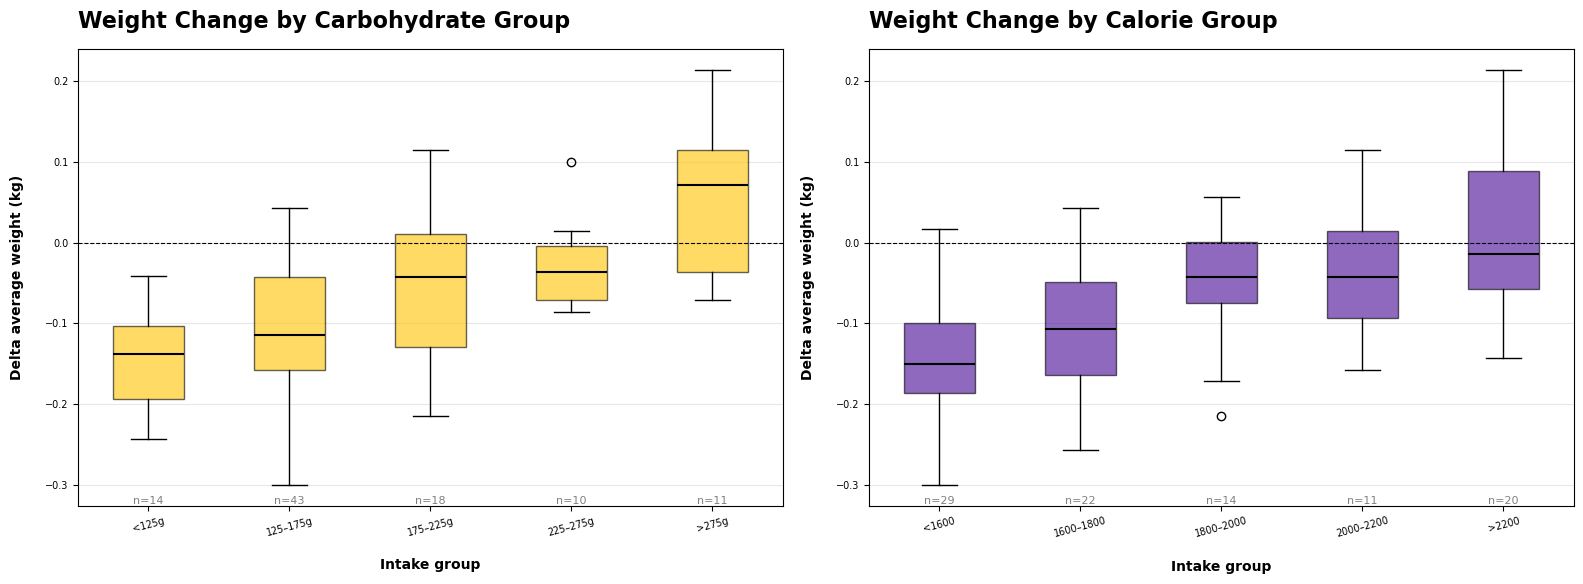

In [70]:
# Carbohydrate bins
carbBins = [0, 125, 175, 225, 275, 1000]
carbLabels = ["<125g", "125–175g", "175–225g", "225–275g", ">275g"]
df["carbGroup"] = pd.cut(df["carbohydrateLag1"], bins = carbBins, labels = carbLabels)

# Calorie bins
calorieBins = [0, 1600, 1800, 2000, 2200, 5000]
calorieLabels = ["<1600", "1600–1800", "1800–2000", "2000–2200", ">2200"]
df["calorieGroup"] = pd.cut(df["calorieLag1"], bins = calorieBins, labels = calorieLabels)

fig, axes = plt.subplots(1, 2, figsize = (16, 6))

for ax, groupCol, groupLabels, title, color in zip(
    axes,
    ["carbGroup", "calorieGroup"],
    [carbLabels, calorieLabels],
    ["Weight Change by Carbohydrate Group", "Weight Change by Calorie Group"],
    [yellow, darkPurple]
):
    groupData = [
        df[df[groupCol] == label]["deltaAverageWeight"].dropna().values
        for label in groupLabels
    ]
    counts = [len(g) for g in groupData]

    bp = ax.boxplot(
        groupData, 
        tick_labels = groupLabels, 
        patch_artist = True,
        widths = 0.5, 
        showfliers = True
    )

    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    # Sample count annotations
    for i, (count, data) in enumerate(zip(counts, groupData)):
        if len(data) > 0:
            ax.text(
                i + 1, 
                ax.get_ylim()[0] if ax.get_ylim()[0] else -0.3,
                f"n={count}", 
                ha = "center", 
                va = "bottom", 
                fontsize = 8, 
                color = "gray"
            )

    ax.axhline(
        0, 
        color = "black", 
        linewidth = 0.8, 
        linestyle = "--"
    )
    ax.set_title(title, loc = "left")
    ax.set_xlabel("Intake group")
    ax.set_ylabel("Delta average weight (kg)")
    ax.tick_params(axis = "x", rotation = 15)
    ax.grid(alpha = 0.3, axis = "y")

plt.tight_layout()
plt.show()

### Findings

**Carbohydrate groups** 
The boxplot shows a stepwise upward progression in median weight change as carbohydrate intake increases. From the <125g group through to the >275g group, each additional bracket shifts the distribution toward less loss or outright gain. The trend is consistent across the first four groups, where dietary behaviour is relatively controlled. The interquartile ranges in the lower carbohydrate brackets are notably tighter, reflecting the consistency of outcome on structured low-carb days.

**Calorie groups** 
The calorie grouping shows a similar directional trend, from approximately −0.14 kg at the lowest intake bracket toward near zero at the highest. However, the pattern is less clean. There is more spread within each box, and the progression between adjacent groups is less consistent. The signal is present but harder to detect in single-day observations, which is precisely why rolling averages were used earlier in the analysis to surface it.

## 16. Residual Weight Modelling

### 16.1 Introduction
Sections above, the data analysis, established my personal TDEE and proved that a sustained caloric deficit produced consistent weight loss. However, calorie alone isn't enough to fully explain daily weight fluctuations. Some days the scale moved more than expected, some days less, with no explanation.

So this machine learning component takes part in a role to ask a more specific question, given yesterday's data (calories, macros, steps, workout, sleep) how much will my weight deviate from the theoretical prediction.

The variable "residual" represents the portion of daily weight change that calories alone couldn't account for. Therefore modelling it isolates its behavioural signal from metabolic noise.

Within this section, two models are applied, namely Ridge and Lasso extended from linear regression that adds penalty terms to prevent overfitting on small datasets like the one I currently have. At 95 observed rows and 5 measured attributes, the standard linear regression risks overfitting and finding patterns in noise that don't generalise trends. 

Because the data I'm observing are dependent on time, ordered chronologically, a standard cross-validation wouldn't work. Splitting train and test sets randomly would allow the model to train on future observations, and test on past ones. So instead of using the standard cross-validation, a walk-forward approach is used to ensure the model always trains on past data and test on next unseen data.

### 16.2 Target Variable
In order to determine the residual we use previously computed data. First, taking my personal TDEE computed in Section 5 representing the weekly rolling average TDEE estimate. Using that made it possible to compute the expected daily weight change. Let 1kg of fat equal to 7700 cal, based on the Wishnofsky's Rule.
$$\text{expected delta} = \frac{\text{calorieLag1} - \text{personalTDEE}}{7700}$$
Then the residual is simply the difference between the actual and expected.
$$\text{residual} = \Delta\text{averageWeight} - \text{expected delta}$$
A positive residual means more weight was gained/less was lost than expected, whilst a negative residual means the body outperformed the prediction. 

In [37]:
df["expectedDelta"] = (df["calorieLag1"] - personalTDEE) / 7700
df["residual"] = df["deltaAverageWeight"] - df["expectedDelta"]

print("Residual Summary")
_res = df["residual"]
print(f"Mean\t:{_res.mean():.4f} kg")
print(f"Std\t:{_res.std():.4f} kg")
print(f"Min\t:{_res.min():.4f} kg")
print(f"Max\t:{_res.max():.4f} kg")
df[["date", "deltaAverageWeight", "expectedDelta", "residual"]].dropna().head(10)

Residual Summary
Mean	:-0.0011 kg
Std	:0.0755 kg
Min	:-0.1741 kg
Max	:0.1779 kg


,date,deltaAverageWeight,expectedDelta,residual
1,2025-12-27,-0.150000,-0.116593,-0.033407
2,2025-12-28,0.016667,-0.125944,0.142611
3,2025-12-29,-0.041667,-0.131009,0.089342
4,2025-12-30,-0.125000,-0.111269,-0.013731
5,2025-12-31,-0.066667,-0.109451,0.042784
6,2026-01-01,-0.147619,-0.128282,-0.019337
7,2026-01-02,-0.200000,-0.128541,-0.071459
8,2026-01-03,-0.200000,-0.104342,-0.095658
9,2026-01-04,-0.242857,-0.120100,-0.122757
10,2026-01-05,-0.242857,-0.111918,-0.130939


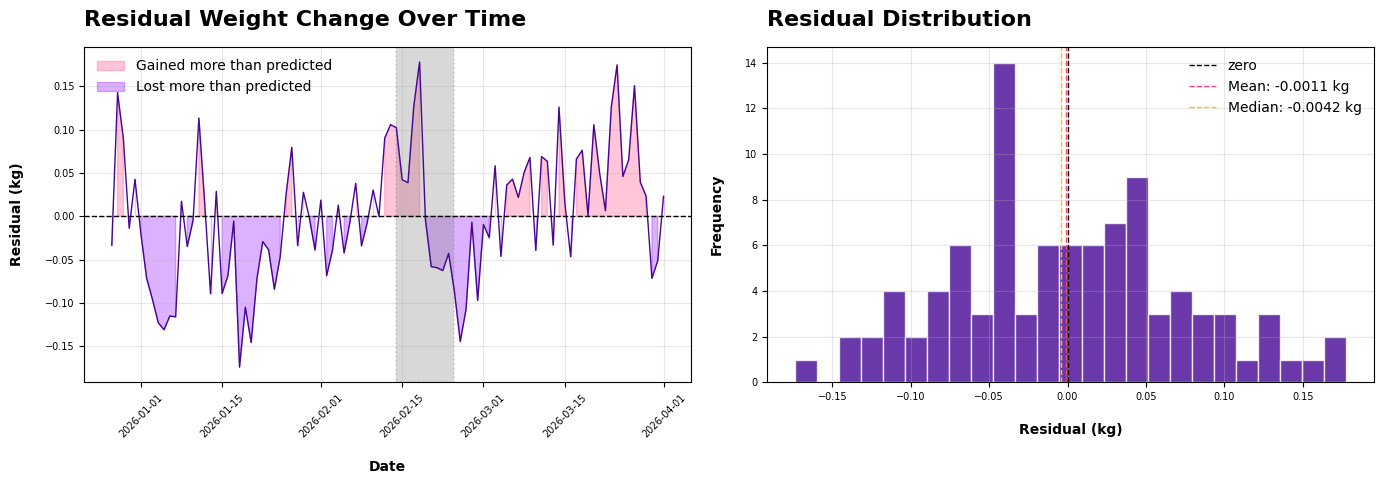

In [38]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Plot 1: Residual Over Time
ax1 = axes[0]
ax1.plot(
    df["date"], df["residual"], 
    color = darkPurple, 
    linewidth = 1
)
ax1.fill_between(
    df["date"], df["residual"],
    0, where = (df["residual"] > 0), 
    alpha = 0.3,
    color = pink,
    label = "Gained more than predicted"
)
ax1.fill_between(
    df["date"], df["residual"],
    0, where = (df["residual"] < 0),
    alpha = 0.3,
    color = purple,
    label = "Lost more than predicted"
)
ax1.axhline(
    0,
    color = "black",
    linewidth = 1,
    linestyle = "--"
)
tripStart = pd.Timestamp("2026-02-14")
tripEnd = pd.Timestamp("2026-02-24")
ax1.axvspan(tripStart, tripEnd, color="gray", linestyle=":", linewidth=1.2, alpha = 0.3)
    
ax1.set_title("Residual Weight Change Over Time", loc = "left")
ax1.set_xlabel("Date")
ax1.set_ylabel("Residual (kg)")
ax1.tick_params(axis = "x", rotation = 45)
ax1.legend()
ax1.grid(alpha = 0.3)

# Plot 2 : Residual Distribution
ax2 = axes[1]
ax2.hist(
    df["residual"].dropna(),
    bins = 25,
    color = darkPurple,
    edgecolor = "white",
    alpha = 0.8
)
ax2.axvline(
    0,
    color = "black",
    linewidth = 1,
    linestyle = "--",
    label = "zero"
)
ax2.axvline(
    df["residual"].mean(),
    color = pink,
    linewidth = 1,
    linestyle = "--",
    label = f"Mean: {_res.mean():.4f} kg"
)
ax2.axvline(
    df["residual"].median(),
    color = yellow,
    linewidth = 1,
    linestyle = "--",
    label = f"Median: {_res.median():.4f} kg"
)
ax2.set_title("Residual Distribution", loc="left")
ax2.set_xlabel("Residual (kg)")
ax2.set_ylabel("Frequency")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Findings

The residual oscillates around zero throughout the observation period with no persistent drift in either direction. This is the result I was hoping to see. This confirms that the personal TDEE estimate is reasonably well-calibrated on average, neither systematically under- nor over-predicting weight change across the dataset. If the TDEE estimate were significantly off, the residuals would drift consistently above or below the zero line over time.

The Indonesia period (grey band) shows a cluster of positive residuals, indicating that the scale moved more than the caloric model predicted. This is consistent with the carbohydrate analysis where higher carb intake during that period increased glycogen and water retention beyond what calories alone would explain, producing unexplained weight above the theoretical prediction.

The distribution confirms the picture quantitatively. The mean residual is −0.0011 kg and the median is −0.0042 kg, both essentially centred at zero. The spread of approximately ±0.1 kg represents the daily noise that energy balance alone cannot account for. This is the portion of weight change that the machine learning model in the following section attempts to explain using behavioural variables from the previous day.

### 16.3 Feature Selection
Not every engineered feature belongs within the model. On a small dataset, adding too many variables may introduce multicollinearity and make the model unstable. The final feature set was therefore chosen through systematic empirical testing rather than intuition alone. Different feature combinations were evaluated using cross-validated Ridge regression $R^2$, and variables were retained or removed depending on whether they improved performance.

#### Feature Selection Journey

Including every available feature initially produced a very poor Ridge $R^2$ of −13.3, indicating overfitting and instability. Through experimentation, I found that retaining only the lag1 versions of variables significantly improved performance, increasing the $R^2$ to −1.46. This likely occurred because multiple lag windows and rolling averages represented highly similar information, causing the features to compete with one another and destabilise the coefficients.

Further improvements came from removing variables that contributed little useful signal. Dropping protein and fat improved the $R^2$ from −1.46 to −0.86. Both variables consistently showed near-zero coefficients, suggesting they were mostly adding noise at this sample size rather than meaningful insight.

Removing sleep improved the $R^2$ again to −0.63. A likely explanation is that sleep duration was strongly associated with the Indonesia phase of the dataset, where my average sleep duration was noticeably higher. As a result, sleep was acting more as a proxy for the travel period rather than an independent predictor of weight fluctuations.

One important observation was that removing steps slightly worsened performance ($R^2$ of −0.65), so the feature was retained. Unlike several other variables, steps appeared to contribute unique information related to daily energy expenditure and activity levels.

Overall, feature selection was driven by generalisation performance rather than attempting to maximise the number of included variables. Features were only retained if they demonstrably improved predictive performance under cross-validation. 

#### Final Selected Features
| Feature |	Reason for Inclusion |
| :-- | :-- |
| calorieLag1 | Primary energy intake signal |
| carbohydrateLag1 | Carbohydrate intake influences glycogen storage and short-term water retention |
| stepLag1 | Represents non exercise activity thermogenesis (NEAT) |
| workoutLag1 | Captures structured exercise and possible post-workout water retention |
| indonesiaPhase | Controls for behavioural and dietary shifts during travel |
#### Excluded Features
| Feature | Reason for Exclusion |
| :-- | :-- |
| proteinLag1 | Near-zero coefficients and reduced generalisation performance |
| fatLag1 | Near-zero coefficients and reduced generalisation performance |
| sleepLag1	| Correlated with Indonesia phase rather than acting as an independent signal |
| Multiple lag windows / rolling averages together | Introduced multicollinearity and destabilised the model |

In [39]:
# Added as a flag to determine the different phases during my diet (deficit/surplus)
df["indonesiaPhase"] = (
    (df["date"] >= "2026-02-15") & (df["date"] <= "2026-02-24")
).astype(int)

features = [
    'calorieLag1',
    'carbohydrateLag1',
    # 'proteinLag1', 
    # 'fatLag1',
    'stepLag1',
    # 'sleepLag1', 
    'workoutLag1',
    # 'calorie3dAverageLag1',
    # 'carbohydrate3dAverageLag1',
    # 'protein3dAverageLag1', 
    # 'fat3dAverageLag1', 
    # 'step3dAverageLag1',
    # 'sleep3dAverageLag1', 
    # 'workout3dAverageLag1',
    # 'calorie7dAverageLag1',
    # 'carbohydrate7dAverageLag1',
    'indonesiaPhase'
]

target = "residual"

dfModel = df[features + [target, "date"]].dropna().reset_index(drop=True)
X = dfModel[features]
y = dfModel[target]
X.head()

,calorieLag1,carbohydrateLag1,stepLag1,workoutLag1,indonesiaPhase
0,1583.0,141.0,8421.0,1.0,0
1,1511.0,128.0,9132.0,1.0,0
2,1472.0,122.0,10352.0,1.0,0
3,1624.0,153.0,8871.0,0.0,0
4,1638.0,156.0,9174.0,0.0,0


### 16.4 Model Pipelines
To ensure consistent feature scaling before training, both Ridge and Lasso regression were implemented using a machine learning pipeline.

The StandardScaler() transformed each feature to have a mean of 0 and a standard deviation of 1. This is important because regularised regression models are sensitive to feature scale. Without scaling, a feature measured in steps (0–15,000) would be penalised far more than one measured in hours (0–10) just because of units.

The Ridge model applied L2 regularisation, which shrinks coefficients toward zero to reduce overfitting and improve stability under multicollinearity. On the other hand, the Lasso model used L1 regularisation, which can force some coefficients exactly to zero, effectively performing automatic feature selection.

The Lasso model was configured with a small regularisation strength alpha = 0.001 and an increased iteration limit max_iter = 10000 to ensure convergence during optimisation.

In [40]:
ridgePipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha = 1.0))
    ]
)

lassoPipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model",  Lasso(alpha = 0.001, max_iter = 10000))
    ]
)

### 16.5 Cross-Validation
To evaluate model performance, an evaluation function was created using time-series cross-validation, unlike the standard random cross-validation. TimeSeriesSplit preserves chronological order by always training on past observations and testing on future observations.

For each fold, the dataset was divided into training and testing segments. The model was trained on the training split and then used to predict the unseen test data. Predictions and actual values were stored to allow later comparison and visualisation.

Three evaluation metrics were calculated for every fold:

- MAE (Mean Absolute Error):  Average absolute prediction error
- RMSE (Root Mean Squared Error): Penalises larger prediction errors more heavily
- $R^2$ (Coefficient of Determination): Measures how much variance in the target variable is explained by the model

Both Ridge and Lasso regression models were evaluated using the same cross-validation procedure to ensure fair comparison. After all folds were completed, the mean performance across folds was calculated to estimate overall generalisation performance.

In [41]:
def evaluateModel(model, X, y, n_splits = 5):
    tscv = TimeSeriesSplit(n_splits = n_splits)
    foldResults = []
    allPredictions = np.full(len(y), np.nan)
    allActualValues = np.full(len(y), np.nan)

    for foldNumber, (trainIndex, testIndex) in enumerate(tscv.split(X)):
        X_train = X.iloc[trainIndex]
        X_test  = X.iloc[testIndex]
        y_train = y.iloc[trainIndex]
        y_test  = y.iloc[testIndex]

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

        allPredictions[testIndex] = predictions
        allActualValues[testIndex] = y_test

        mae  = mean_absolute_error(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        r2   = r2_score(y_test, predictions)

        foldResults.append({
            "Fold": foldNumber + 1,
            "Training samples": len(trainIndex),
            "Testing samples": len(testIndex),
            "MAE": mae,
            "RMSE": rmse,
            "R²": r2
        })

    resultsDf = pd.DataFrame(foldResults)
    return resultsDf, allPredictions, allActualValues


print("Ridge Regression Results")
ridgeResults, ridgePredictions, ridgeActuals = evaluateModel(ridgePipeline, X, y)

print(ridgeResults.to_string(index=False))


print("\nLasso Regression Results")
lassoResults, lassoPredictions, lassoActuals = evaluateModel(lassoPipeline, X, y)

print(lassoResults.to_string(index=False))


summaryDf = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],

    "Average MAE": [
        ridgeResults["MAE"].mean(),
        lassoResults["MAE"].mean()
    ],

    "Average RMSE": [
        ridgeResults["RMSE"].mean(),
        lassoResults["RMSE"].mean()
    ],

    "Average R²": [
        ridgeResults["R²"].mean(),
        lassoResults["R²"].mean()
    ]
})

print("\nCross Validation Performance")
print(summaryDf.to_string(index=False))

Ridge Regression Results
 Fold  Training samples  Testing samples      MAE     RMSE        R²
    1                16               16 0.062966 0.077007 -0.396057
    2                32               16 0.040191 0.052314 -0.859098
    3                48               16 0.072239 0.086210  0.115008
    4                64               16 0.056477 0.066139 -0.795628
    5                80               16 0.078344 0.095735 -1.205297

Lasso Regression Results
 Fold  Training samples  Testing samples      MAE     RMSE        R²
    1                16               16 0.062789 0.076959 -0.394338
    2                32               16 0.040217 0.052014 -0.837870
    3                48               16 0.093282 0.117381 -0.640694
    4                64               16 0.057188 0.066978 -0.841521
    5                80               16 0.066258 0.084797 -0.730132

Cross Validation Performance
Model  Average MAE  Average RMSE  Average R²
Ridge     0.062043      0.075481   -0.628214
L

In [42]:
ridgePipeline.fit(X, y)
lassoPipeline.fit(X, y)

ridgeCoefs = ridgePipeline.named_steps["model"].coef_ / ridgePipeline.named_steps["scaler"].scale_
lassoCoefs = lassoPipeline.named_steps["model"].coef_ / lassoPipeline.named_steps["scaler"].scale_

coefDf = pd.DataFrame({
    "Feature":    features,
    "Ridge Coef": ridgeCoefs,
    "Lasso Coef": lassoCoefs,
}).sort_values("Ridge Coef", key=abs, ascending=False)

print("Final Model Coefficients")
print(coefDf.to_string(index=False))

print("\nLasso Feature Selection")
lassoSelected = coefDf[coefDf["Lasso Coef"] != 0][["Feature", "Lasso Coef"]]
lassoDropped  = coefDf[coefDf["Lasso Coef"] == 0][["Feature"]]
print("Retained:")
print(lassoSelected.to_string(index=False))
print("\nEliminated:")
print(lassoDropped.to_string(index=False))

Final Model Coefficients
         Feature  Ridge Coef  Lasso Coef
  indonesiaPhase   -0.039654   -0.030476
     workoutLag1    0.018347    0.013663
carbohydrateLag1    0.000640    0.000477
     calorieLag1   -0.000018   -0.000000
        stepLag1    0.000007    0.000007

Lasso Feature Selection
Retained:
         Feature  Lasso Coef
  indonesiaPhase   -0.030476
     workoutLag1    0.013663
carbohydrateLag1    0.000477
        stepLag1    0.000007

Eliminated:
    Feature
calorieLag1


### 16.6 Coefficient Interpretation

The regression coefficients describe how much the predicted residual weight changes for a one-unit increase in each feature, while holding the remaining variables constant.

carbohydrateLag1 showed the most consistent positive relationship across both Ridge and Lasso regression. Higher carbohydrate intake on the previous day was associated with higher next-day residual weight. This is physiologically reasonable, as glycogen storage is accompanied by water retention, temporarily increasing body weight.

workoutLag1 also produced a positive coefficient in both models. This may reflect short-term inflammation and water retention during muscle recovery after exercise. However, the scale of the effect was relatively small, so the interpretation should remain cautious.

IndonesiaPhase consistently produced a negative coefficient in both models. Even after adjusting for calorie consumption, carbs, exercises, and steps, the Indonesia phase was still associated with decreased residual weight. This indicates that the phase captured additional behavioural or environmental impacts that were not fully represented by the recorded variables.

calorieLag1 was effectively eliminated by the Lasso model, indicating that calorie intake did not contribute meaningful independent predictive information once the other variables were included. Similarly, stepLag1 produced only a very small coefficient in both models, suggesting a comparatively weak signal at this sample size.

Overall, the most interpretable findings were the positive relationship between carbohydrate intake and residual weight, and the consistently negative relationship associated with the Indonesia phase.

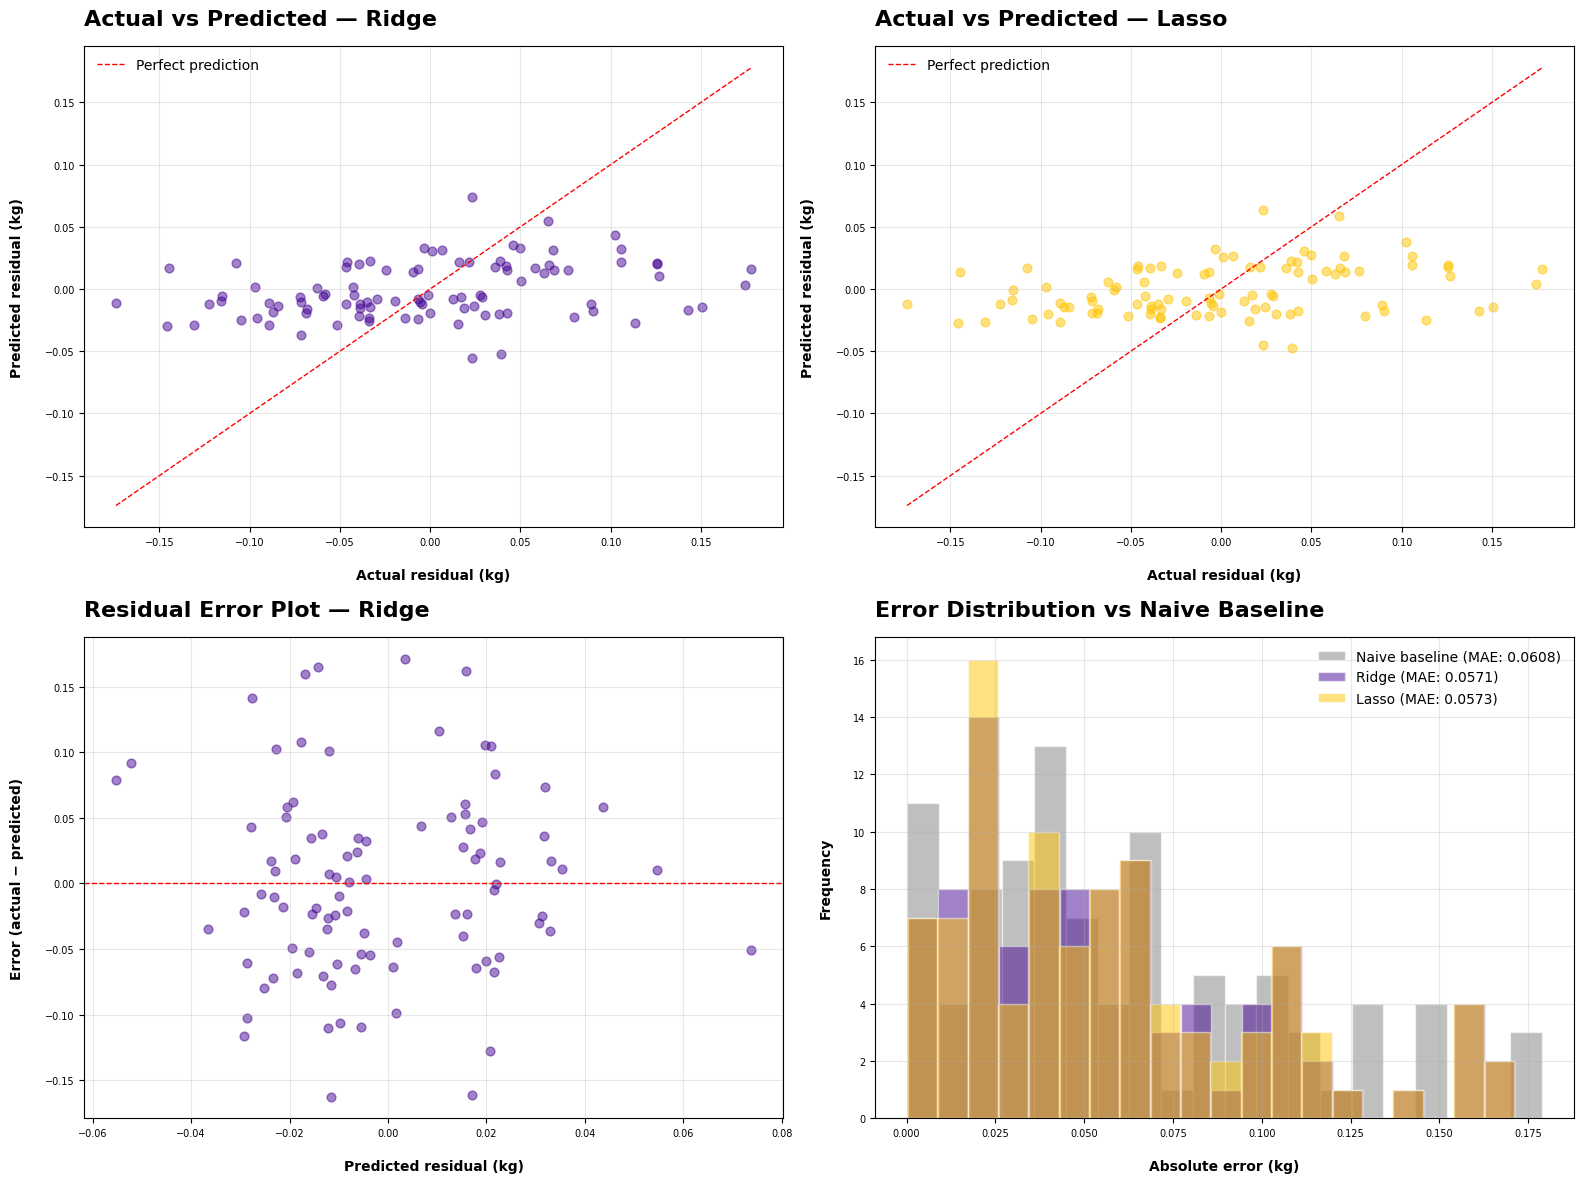

In [43]:
ridgePred = ridgePipeline.predict(X)
lassoPred = lassoPipeline.predict(X)

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

# --- Plot 1: Actual vs Predicted (Ridge) ---
ax1 = axes[0, 0]
ax1.scatter(
    y, ridgePred, 
    alpha = 0.5, 
    color = darkPurple, 
    s = 40, 
)
lims = [min(y.min(), ridgePred.min()), max(y.max(), ridgePred.max())]
ax1.plot(
    lims, lims, 
    linewidth=1, 
    linestyle = "--",
    color = "red",
    label="Perfect prediction")
ax1.set_title("Actual vs Predicted — Ridge", loc="left")
ax1.set_xlabel("Actual residual (kg)")
ax1.set_ylabel("Predicted residual (kg)")
ax1.legend()
ax1.grid(alpha = 0.3)

# --- Plot 2: Actual vs Predicted (Lasso) ---
ax2 = axes[0, 1]
ax2.scatter(
    y, lassoPred, 
    alpha = 0.5, 
    color = yellow, 
    s = 40
)
ax2.plot(
    lims, lims, 
    linewidth=1, 
    linestyle = "--",
    color = "red",
    label="Perfect prediction")
ax2.set_title("Actual vs Predicted — Lasso", loc = "left")
ax2.set_xlabel("Actual residual (kg)")
ax2.set_ylabel("Predicted residual (kg)")
ax2.legend()
ax2.grid(alpha = 0.3)

# --- Plot 3: Residual error plot ---
ax3 = axes[1, 0]
modelErrors = y - ridgePred
ax3.scatter(
    ridgePred, modelErrors, 
    alpha = 0.5, 
    color = darkPurple,
    s = 40
)

ax3.axhline(
    0, 
    color = "red", 
    linewidth = 1, 
    linestyle = "--"
)
ax3.set_title("Residual Error Plot — Ridge", loc = "left")
ax3.set_xlabel("Predicted residual (kg)")
ax3.set_ylabel("Error (actual − predicted)")
ax3.grid(alpha = 0.3)

# Plot 4: Naive baseline comparison ---
ax4 = axes[1, 1]
naivePred = np.full(len(y), y.mean())
naiveErrors = np.abs(y - naivePred)
ridgeErrors = np.abs(y - ridgePred)
lassoErrors = np.abs(y - lassoPred)

ax4.hist(
    naiveErrors, 
    bins = 20, 
    alpha = 0.5, 
    color = "gray",
    edgecolor = "white", 
    label = f"Naive baseline (MAE: {naiveErrors.mean():.4f})"
)
ax4.hist(
    ridgeErrors, 
    bins = 20, 
    alpha = 0.5, 
    color = darkPurple,
    edgecolor = "white", 
    label = f"Ridge (MAE: {ridgeErrors.mean():.4f})"
)
ax4.hist(
    lassoErrors, 
    bins = 20, 
    alpha = 0.5, 
    color = yellow,
    edgecolor = "white", 
    label = f"Lasso (MAE: {lassoErrors.mean():.4f})"
)
ax4.set_title("Error Distribution vs Naive Baseline", loc = "left")
ax4.set_xlabel("Absolute error (kg)")
ax4.set_ylabel("Frequency")
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Findings

The Actual vs Predicted plots for both Ridge and Lasso show predictions clustered tightly around zero regardless of the true residual value. Points do not follow the diagonal, which would represent a well-performing model. This is consistent with the negative cross-validated R² reported in the evaluation the model fails to generalise, producing predictions close to the mean of the target rather than tracking individual variation. Both models behave similarly, confirming that the issue is one of data quantity rather than model choice.

The residual error plot shows errors scattered randomly around zero with no visible systematic pattern. This is actually an encouraging result, it means the model is not making directionally biased predictions in a consistent way. The errors are symmetric and unstructured, which suggests the model has not learned a spurious pattern that it is confidently applying in the wrong direction.

In the error distribution chart, both Ridge (MAE: 0.0571) and Lasso (MAE: 0.0573) produce lower training errors than the naive baseline (MAE: 0.0608). This confirms that the models did learn something real from the training data. However, 95 observations across two meaningfully different dietary phases is not enough data to isolate and generalise that signal to unseen days.

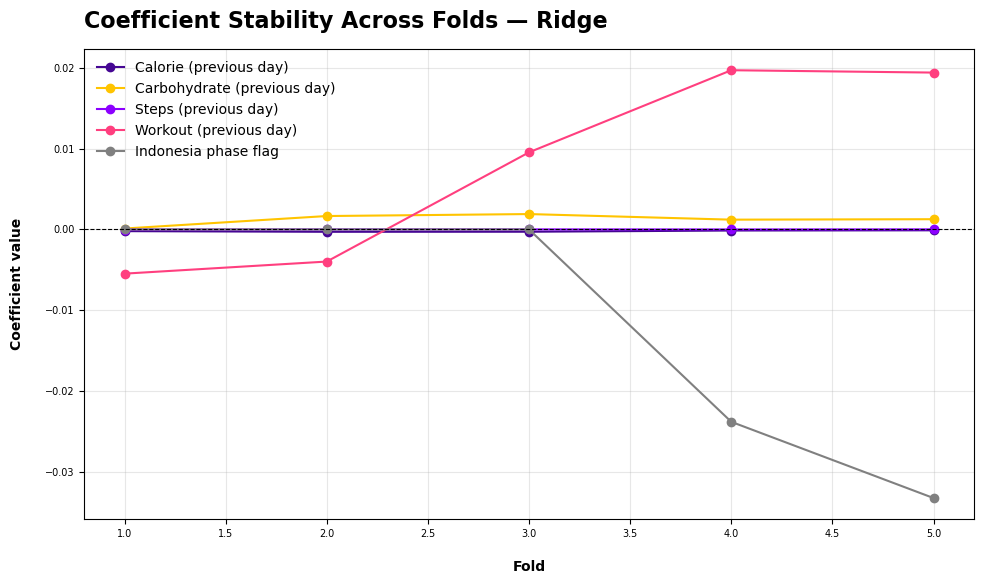


Coefficient Stability Summary
      calorieLag1  carbohydrateLag1      stepLag1  workoutLag1  indonesiaPhase
Fold                                                                          
1       -0.000207          0.000114 -1.254335e-05    -0.005458        0.000000
2       -0.000289          0.001659  9.188940e-06    -0.003965        0.000000
3       -0.000281          0.001902  7.520085e-06     0.009527        0.000000
4       -0.000131          0.001211 -6.093828e-07     0.019669       -0.023762
5       -0.000105          0.001267  1.113758e-05     0.019378       -0.033177


In [72]:
# Refit on each fold and record coefficients
tscv = TimeSeriesSplit(n_splits = 5)
foldCoefs = []

for fold, (trainIdx, testIdx) in enumerate(tscv.split(X)):
    X_train = X.iloc[trainIdx]
    y_train = y.iloc[trainIdx]

    ridgePipeline.fit(X_train, y_train)
    coefs = ridgePipeline.named_steps["model"].coef_ / ridgePipeline.named_steps["scaler"].scale_

    foldCoefs.append({
        "Fold": fold + 1,
        **dict(zip(features, coefs))
    })

foldCoefDf = pd.DataFrame(foldCoefs).set_index("Fold")

coefLabels = {
    "calorieLag1": "Calorie (previous day)",
    "carbohydrateLag1": "Carbohydrate (previous day)",
    "stepLag1": "Steps (previous day)",
    "workoutLag1": "Workout (previous day)",
    "indonesiaPhase": "Indonesia phase flag",
}
coefColors = {
    "calorieLag1":      darkPurple,
    "carbohydrateLag1": yellow,
    "stepLag1":         purple,
    "workoutLag1":      pink,
    "indonesiaPhase":   "gray",
}

fig, ax = plt.subplots(figsize = (10, 6))
for feature in features:
    ax.plot(
        foldCoefDf.index, foldCoefDf[feature],
        marker = "o",
        color = coefColors.get(feature, "black"),
        label = coefLabels.get(feature, feature),
        linewidth = 1.5
    )

ax.axhline(
    0, 
    color = "black",
    linewidth = 0.8, 
    linestyle = "--"
)
ax.set_title("Coefficient Stability Across Folds — Ridge", loc = "left")
ax.set_xlabel("Fold")
ax.set_ylabel("Coefficient value")
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

print("\nCoefficient Stability Summary")
print(foldCoefDf.to_string())

## 17. Conclusion

### Key Results at a Glance

| Metric | Value |
| :-- | :-- |
| Observation period | 95 days (26 Dec 2025 – 1 Apr 2026) |
| Personal TDEE (data-derived) | **2,481 kcal/day** |
| Mifflin-St Jeor estimate | 2,697 kcal/day |
| Difference from formula | −216 kcal/day |
| Average weekly weight loss | **0.56 kg/week** |
| Total weight lost | 7.4 kg |
| Carbohydrate effect on scale | ~0.064 kg per 100g (next-day) |
| Ridge MAE vs naive baseline | 0.057 kg vs 0.061 kg |

---

### What Is This Project
Originally this project began with a simple but frustrating fact that I don't know my personal TDEE well enough to diet without discomfort. Standard formulas only gave numbers that didn't reflect reality. So my first weeks of dieting on an unhealthily aggressive deficit were mentally and physically draining. This simple problem would've been entirely avoidable if I had a better understanding of my personal TDEE.

### What the Analysis Found
My Personal TDEE
The analysis answered my main objective, to derive my personal TDEE. The data-derived personal TDEE estimate deviates from the Mifflin-St Jeor formula. This confirms that general calculators serve as a starting point, not a personal answer. A self-collected dataset, even a modest one, produces a more calibrated individual estimate, which has since helped me maintain a sustainable diet.

**Carbohydrates as the primary source of weight noise**
Across every analytical approach, whether it’s from the correlation analysis, scatter plots, 
boxplots, and the machine learning model, carbohydrate intake showed that it is the most consistent and interpretable driver of unexplained weight change. Higher carb intake the day before reliably produced more scale weight the day measured, disregarding total caloric intake. A representation of how glycogen and water retention distorts scale weight.
The final model quantified personally that for every 100 gram of carbohydrates is associated 
with approximately 0.064 kg of unexplained next-day weight gain. 

Different phases in the dataset
My time in Indonesia is a natural dietary experiment embedded in the dataset, which dominated many of the correlations observed throughout the analysis. This is both a limitation and a finding. It confirms that dietary context matters as much as individual variables, and that a dataset spanning two meaningfully different behavioural phases requires careful interpretation to separate genuine variable effects from phase-level confounding. 

### What the Machine Learning Found

The regularised regression models, Ridge and Lasso, produced a mean cross-validation R² of −0.63. A negative R² means the model learned patterns that are misleading it on new data, and it would’ve been better off knowing nothing. So, truthfully, the model’s predictions are worse than just predicting the mean.

Two findings from the model are reliable and stable across all folds:

- Carbohydrate intake carries a consistently positive coefficient, it's directionally correct and stable regardless of which observations are in the training set.
- The Indonesia phase flag carries a consistently negative coefficient, growing stronger as the model sees more data, confirming the phase effect is real and consistent.

However, one finding is unreliable. Workout flips sign between folds, meaning its effect cannot be interpreted at this sample size despite appearing significant in the full model fit.

The model beats the naive baseline on training data (Ridge MAE 0.057 vs naive 0.061), confirming genuine learning occurred. The failure to generalise unseen data is a data quantity and data richness problem and not a modelling error.


### Limitations

Sample size at only 95 observations is insufficient to reliably separate correlated predictors. The coefficient instability observed in the stability analysis is a direct consequence of this.

Missing variables. Some attributes that may be considered drivers of day-to-day TDEE fluctuation like resting heart rate, training volume, stress, and hormonal state aren’t present. The dataset captures behaviour but not the physiological response to that behaviour.

Two-phase confounding, the Indonesia period introduces a structural shift in the dataset that limits the ability to isolate individual variable effects. A longer dataset from a single consistent dietary phase would produce cleaner signals.

Measurement error, calorie logging is an estimate, particularly on days without precise measurement. Under or over estimating intake would shift TDEE.

### What Would Improve This Project

Continuing data collection is the single highest-leverage improvement, alongside a consistent dietary phase. The models could perform better, stabilise, coefficients would become interpretable, and the question of whether carbohydrates independently drive residual weight change, controlling for calories and activity, could be answered with confidence.

In addition, the following variables would be worth logging:
- Resting heart rate 
- Training volume
- A daily stress or energy rating
- Sleep Quality

These additions, combined with a larger dataset, would transform this from a data-limited exploratory analysis into a genuinely predictive personal model.


### Final Reflection

The 0.56 kg weekly average loss achieved over this period was not the result of perfect knowledge, it was achieved despite uncertainty, and in the early weeks, at the cost of unnecessary discomfort. This project is the retrospective answer to that uncertainty.

The finding that matters most is not the R² or the coefficients, it is that a personally derived TDEE estimate, built from nothing more than a simple spreadsheet table and consistent daily logging, is both achievable and more accurate than a generic formula. Anyone willing to collect the data can build a better estimate of their own metabolism than any calculator provides.

That is the practical conclusion of this project.

